# Notebook 1 of 3 — Research Foundations: Statistically Certified Face Redaction for Egocentric Video

This is a **research-grounded starting point**, not a record of production experience. It is the
academic foundation of a 3-notebook portfolio series built for the Upwork job *"Face redaction for
egocentric household video."* The client licenses head-mounted (4K, ~30 fps) footage of household
cleaning to robotics / embodied-AI companies and needs an unattended CLI that blurs every face before
footage leaves their systems, with three hard numbers: **recall ≥ 99% per face instance, precision ≥
95%, minimum $/video-hour**. Faces are rare (whole episodes can have zero), the faces that do appear are
hard (mirrors, profile, small, children, motion blur), domestic distractors (TV faces, photos,
packaging, toys) cause false positives, and frames within an episode are temporally dependent. The
client cannot currently measure recall on their own footage, and they have said explicitly that *how*
99% will be proven matters more than any specific number.

Three papers carry the statistics as one story, **calibrate → decide → certify**:

- **P1 — Learn then Test (LTT).** Angelopoulos, Bates, Candès, Jordan, Lei. arXiv:2110.01052;
  *Annals of Applied Statistics* 19(2), 2025. Picks a configuration that controls one or several risks
  jointly **with probability ≥ 1−δ**, then the cheapest such configuration.
- **P2 — Conformal Object Detection by Sequential Risk Control (SeqCRC).** Andéol, Mossina, Mazoyer,
  Gerchinovitz. arXiv:2505.24038. Detection-specific losses, matching, and multiplicative box margins;
  recall control **in expectation**; precision explicitly **not** guaranteed.
- **P3 — Finite-Sample Coverage Audits for High-Recall Candidate Generation.** Anthony, Salehzadeh
  Nobari. arXiv:2607.21480. Exact finite-sample certificates for missed relevant mass, the label
  complexity of proving it, and what a "no misses on our sample" claim cannot show.

**This notebook derives each paper's core estimator, test, or certificate and verifies every guarantee
by simulation**, reproducing the papers' own quoted numbers where possible — kept **visibly separate**
from toy numbers used purely to exercise the machinery. Every claim is tagged either with its paper and
research-query slug (e.g. `[P3 Thm 7, facered-q7]`) or marked **"derived here"** when it is not in any
of the three papers. Notebook 2 will build a synthetic egocentric-episode simulator and a per-frame
detector baseline on top of the machinery derived here; Notebook 3 will use it to decide a configuration
and certify it on a sealed audit.

In [1]:
# This environment's matplotlib defaults to the non-interactive 'agg' backend (no display
# attached); %matplotlib inline switches a real Jupyter kernel to the inline backend so charts
# render normally. Run this once, first cell.
%matplotlib inline

import time
t_notebook_start = time.time()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RNG_SEED = 20260917
rng = np.random.default_rng(RNG_SEED)

# ---------------------------------------------------------------------------------------
# One palette, defined once, reused in every visualization cell in this notebook.
# ---------------------------------------------------------------------------------------
PALETTE = {
    "crc":    "#d95f02",  # orange  -- SeqCRC / CRC: expectation-only control (P2)
    "ltt":    "#1b9e77",  # teal    -- LTT: (alpha,delta)-risk-controlling prediction (P1)
    "cert":   "#7570b3",  # purple  -- P3 audit certificates (Clopper-Pearson / hypergeometric)
    "target": "#000000",  # black   -- alpha / delta / target reference lines
    "bad":    "#e7298a",  # magenta -- under-coverage, failure, naive/frame-level baselines
    "aux":    "#66a61e",  # green   -- secondary series, paper reference points, track-level
}

# ---------------------------------------------------------------------------------------
# Clopper-Pearson one-sided bounds [P3 Sec. 4, facered-q7]:
#   U_n(k, alpha) := sup{q in [0,1] : P(Bin(n,q) <= k) >= alpha}
#   L_n(k, alpha) := inf{q in [0,1] : P(Bin(n,q) >= k) >= alpha}
# Closed form via the beta quantile function (standard identity between the binomial tail
# and the incomplete beta function): U_n(k,alpha) = Beta^{-1}(1-alpha; k+1, n-k) for k<n, and
# 1 for k=n. Symmetric identity gives L_n(k,alpha) = Beta^{-1}(alpha; k, n-k+1) for k>0, and 0
# for k=0. alpha here plays the role of a FAILURE probability (e.g. delta), matching the
# papers' usage such as U_n(0,alpha) = 1 - alpha^(1/n).
# ---------------------------------------------------------------------------------------
def clopper_pearson_upper(k, n, alpha):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    safe_nk = np.maximum(n - k, 1e-12)
    return np.where(k >= n, 1.0, stats.beta.ppf(1 - alpha, k + 1, safe_nk))


def clopper_pearson_lower(k, n, alpha):
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    safe_k = np.maximum(k, 1e-12)
    return np.where(k <= 0, 0.0, stats.beta.ppf(alpha, safe_k, np.maximum(n - k + 1, 1e-12)))


# Self-check: closed-form zero-count formula U_n(0, alpha) = 1 - alpha^(1/n) [P3 Sec. 4] vs the
# general beta-quantile form above.
n_chk, alpha_chk = 300, 0.05
u_closed = 1 - alpha_chk ** (1 / n_chk)
u_beta = float(clopper_pearson_upper(0, n_chk, alpha_chk))
ok = abs(u_closed - u_beta) < 1e-9
print(f"CHECK 0.1: U_300(0,0.05) closed-form {u_closed:.6f} vs beta-quantile form {u_beta:.6f} "
      f"-> {'PASS' if ok else 'FAIL'}")

CHECK 0.1: U_300(0,0.05) closed-form 0.009936 vs beta-quantile form 0.009936 -> PASS


## 1. Three kinds of guarantee: expectation, (α,δ)-probability, and exact certificate

The three papers make **structurally different** promises, and confusing them is the single most
dangerous mistake in this whole pipeline.

- **(a) SeqCRC / CRC — expectation control.** `[P2 Thm. 1 Eq. 2, Thm. 2 Eq. 7, facered-q4]`
  > "α − 2B/(n+1) ≤ E[L_test(λ̂)] ≤ α" (Eq. 2); Theorem 2: "E[L_test^•(λ_cnf^+, λ_•^+)] ≤ α_•" (Eq. 7).
  > "Importantly, the above expectation is over both D_cal and (X_test,Y_test) … There is no
  > guarantee that (2) holds for all possible test instances, or for all calibration data sets."
  There is **no δ** anywhere in this guarantee — it is a statement about the *average* risk over the
  randomness of calibration **and** test data jointly, not about any one calibration draw.
- **(b) LTT — (α,δ)-risk-controlling prediction.** `[P1 Def. 1, Thm. 1, facered-q1, facered-q2]`
  > "Definition 1 (Risk-controlling prediction). Let λ̂ ∈ Λ be a random variable. We say that T_λ̂ is
  > an (α,δ)-risk-controlling prediction (RCP) if P(R(T_λ̂) ≤ α) ≥ 1−δ."
  > "Theorem 1 … P(sup_{λ∈Λ̂}{R(λ)} ≤ α) ≥ 1−δ, where the supremum over an empty set is defined as −∞."
  The probability is **over the calibration sample**: with probability ≥ 1−δ, *this particular
  calibration draw* yields a λ̂ whose true risk is ≤ α. δ is a knob the user sets.
- **(c) P3 — one-sided audit certificates.** `[P3 Thm. 7, facered-q7]`
  > "Theorem 7 (Excluded-pool binomial certificate) … with probability at least 1−δ,
  > η(g) ≤ U_{n0}(K0(g), δ/|G|) and r(g) ≤ p0(g)·U_{n0}(K0(g), δ/|G|) for all g ∈ G."
  Same probability-over-the-audit-sample flavor as LTT, but built from an **exact** Clopper–Pearson
  inversion of the binomial tail rather than a concentration inequality, and it certifies a specific,
  already-*deployed* generator on a sealed sample rather than choosing among a grid.

**Toy simulation (derived here).** A single score-threshold problem with a binary miss loss lets us put
(a) and (b) side by side on *identical data*. Let X ~ Beta(2,2) be a detector's confidence score for a
genuine face instance, and let λ ∈ [0,1] parametrize an admission threshold at `1−λ` (so λ=1 admits
everything, λ=0 admits nothing — this makes the loss **non-increasing in λ**, matching Assumption 2
`[P2, facered-q4]`). The miss loss is L(λ) = 1{X < 1−λ}; the **true risk is analytic**,
R(λ) = P(X < 1−λ) = F_{Beta(2,2)}(1−λ), so we can score every calibration draw's chosen λ exactly,
without a huge held-out test set.

Over many independent calibration draws of size n we compute λ̂_CRC (Eq. 1, B=1) and λ̂_LTT (exact
binomial p-value, single fixed-sequence test at level δ, following Algorithm 1 `[P1, facered-q2]`), then
look up each draw's **true** risk R(λ̂). CRC's guarantee is about the *average* of this column across
draws; LTT's is about what *fraction* of draws land below α.

In [2]:
# Toy score-threshold problem: X ~ Beta(2,2) is a detector confidence for a genuine face instance.
# lambda in [0,1] sets an admission threshold at (1 - lambda); loss(lambda) = 1{X < 1-lambda} is
# non-increasing in lambda (Assumption 2 style: bigger lambda = more permissive = safer).
# True risk R(lambda) = P(X < 1-lambda) = Beta(2,2).cdf(1-lambda) is exactly computable.
n_cal_s1 = 200          # calibration draw size
D_s1 = 2000             # number of independent calibration draws (Monte Carlo replicates)
alpha_s1 = 0.05         # toy target miss rate
delta_s1 = 0.10         # LTT error level (P1 default, facered-q10)
B_s1 = 1.0
lam_grid_s1 = np.linspace(0.0, 1.0, 201)  # ascending lambda

beta22 = stats.beta(2, 2)
true_risk_curve_s1 = beta22.cdf(1 - lam_grid_s1)  # non-increasing in lambda, exact

rng_s1 = np.random.default_rng(RNG_SEED + 1)
X_s1 = rng_s1.beta(2, 2, size=(D_s1, n_cal_s1))  # (D, n)

# Empirical risk Rhat(lambda) per draw, for every grid point: fraction of X_i < 1-lambda.
# Vectorized over (draws, samples, grid).
thresholds = 1 - lam_grid_s1  # (G,)
miss_counts = (X_s1[:, :, None] < thresholds[None, None, :]).sum(axis=1)  # (D, G)
Rhat_s1 = miss_counts / n_cal_s1  # (D, G), non-increasing in lambda by construction

# --- CRC selection (Eq. 1): lambda_hat = inf{lambda : (n*Rhat + B)/(n+1) <= alpha} ---
crc_lhs = (n_cal_s1 * Rhat_s1 + B_s1) / (n_cal_s1 + 1)   # (D, G), non-increasing in lambda
crc_ok = crc_lhs <= alpha_s1
crc_has_valid = crc_ok.any(axis=1)
crc_idx = np.where(crc_has_valid, np.argmax(crc_ok, axis=1), len(lam_grid_s1) - 1)  # inf empty -> max lambda
lam_hat_crc = lam_grid_s1[crc_idx]
true_risk_crc = beta22.cdf(1 - lam_hat_crc)

# --- LTT selection: exact binomial p-value, single fixed-sequence test, descending lambda order ---
# p_j = P(Bin(n, alpha) <= ceil(n*Rhat_j))  [exact binomial tail, P1 Sec. 3.2, facered-q2]
p_bin_s1 = stats.binom.cdf(np.ceil(n_cal_s1 * Rhat_s1), n_cal_s1, alpha_s1)  # (D, G)
# Test lambda = 1 (safest) down to lambda = 0 (riskiest): reverse the ascending grid.
p_desc = p_bin_s1[:, ::-1]              # column 0 = lambda=1, column G-1 = lambda=0
reject = p_desc <= delta_s1
accept_prefix = np.cumprod(reject.astype(int), axis=1)  # 1 while still accepting, 0 after first failure
n_accepted = accept_prefix.sum(axis=1)   # 0 if the very first test already fails -> Lambda_hat empty
ltt_abstain = n_accepted == 0
lam_desc = lam_grid_s1[::-1]
lam_hat_ltt = np.where(ltt_abstain, np.nan, lam_desc[np.clip(n_accepted - 1, 0, None)])
true_risk_ltt = np.where(ltt_abstain, np.nan, beta22.cdf(1 - np.nan_to_num(lam_hat_ltt)))

frac_abstain = ltt_abstain.mean()
mean_risk_crc = true_risk_crc.mean()
frac_violate_crc = (true_risk_crc > alpha_s1).mean()
frac_violate_ltt = np.nanmean(true_risk_ltt > alpha_s1)  # among non-abstaining draws

print(f"CHECK 1.1: mean true risk of CRC across {D_s1} draws = {mean_risk_crc:.4f} <= alpha={alpha_s1} "
      f"-> {'PASS' if mean_risk_crc <= alpha_s1 else 'FAIL'}")
print(f"CHECK 1.2: fraction of CRC draws with true risk > alpha = {frac_violate_crc:.3f} "
      f"(expectation control allows large per-draw violation; expected to be a sizeable fraction, "
      f"not near 0) -> {'PASS (non-trivial fraction observed)' if frac_violate_crc > 0.05 else 'FAIL (unexpectedly small)'}")
print(f"CHECK 1.3: LTT abstain fraction (Lambda_hat empty) = {frac_abstain:.3f} [reportable outcome, P1 Sec 1.1]")
tol_s1 = 3 * np.sqrt(delta_s1 * (1 - delta_s1) / D_s1)
print(f"CHECK 1.4: fraction of non-abstaining LTT draws with true risk > alpha = {frac_violate_ltt:.4f} "
      f"<= delta={delta_s1} (+MC tol {tol_s1:.4f}) "
      f"-> {'PASS' if frac_violate_ltt <= delta_s1 + tol_s1 else 'FAIL'}")

CHECK 1.1: mean true risk of CRC across 2000 draws = 0.0476 <= alpha=0.05 -> PASS
CHECK 1.2: fraction of CRC draws with true risk > alpha = 0.357 (expectation control allows large per-draw violation; expected to be a sizeable fraction, not near 0) -> PASS (non-trivial fraction observed)
CHECK 1.3: LTT abstain fraction (Lambda_hat empty) = 0.000 [reportable outcome, P1 Sec 1.1]
CHECK 1.4: fraction of non-abstaining LTT draws with true risk > alpha = 0.0415 <= delta=0.1 (+MC tol 0.0201) -> PASS


#### How to read this chart

Two overlapping histograms of the **true** risk R(λ̂) achieved on each of the 2,000 calibration draws —
orange for CRC, teal for LTT — with a black dashed line at the toy target α=0.05. CRC's mass is spread
on both sides of the line (its guarantee is only about the *mean* of this histogram, printed in
CHECK 1.1); LTT's mass should sit overwhelmingly at or below the line, with only a δ=0.10 tail (or
fewer draws, since LTT can also abstain) allowed to cross it. For the face-redaction job this is the
whole reason LTT, not SeqCRC alone, is used to *decide* a configuration: only LTT's histogram supports
the sentence "with probability ≥ 90%, *this* calibration run's chosen configuration has recall risk
≤ target."

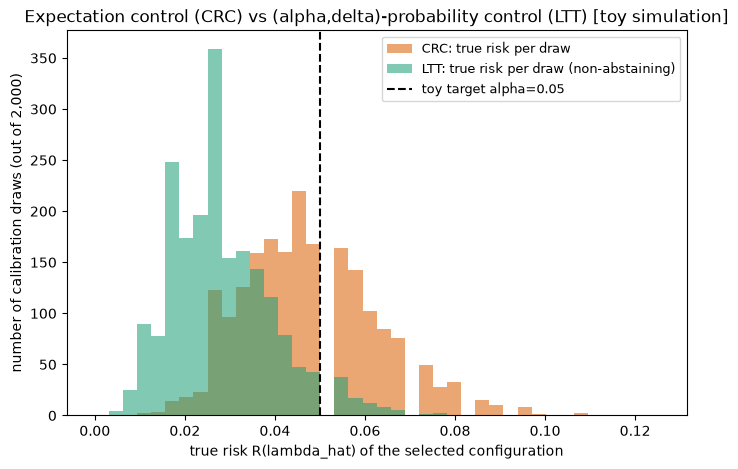

In [3]:
# VIZ
fig, ax = plt.subplots(figsize=(8, 5))
hi = float(max(np.nanmax(true_risk_crc), np.nanmax(true_risk_ltt), alpha_s1)) * 1.15
bins = np.linspace(0, hi, 41)
ax.hist(true_risk_crc, bins=bins, alpha=0.55, color=PALETTE["crc"], label="CRC: true risk per draw")
ax.hist(true_risk_ltt[~np.isnan(true_risk_ltt)], bins=bins, alpha=0.55, color=PALETTE["ltt"],
        label="LTT: true risk per draw (non-abstaining)")
ax.axvline(alpha_s1, color=PALETTE["target"], linestyle="--", label=f"toy target alpha={alpha_s1}")
ax.set_xlabel("true risk R(lambda_hat) of the selected configuration")
ax.set_ylabel("number of calibration draws (out of 2,000)")
ax.set_title("Expectation control (CRC) vs (alpha,delta)-probability control (LTT) [toy simulation]")
ax.legend(fontsize=9)
plt.show()

## 2. LTT machinery: p-values, FWER control, fixed sequences, and multiple risks

LTT turns "is R(λ) ≤ α?" into a multiple-testing problem over a grid Λ, with null hypotheses
H_j: R(λ_j) > α `[P1 Sec. 2.1, facered-q2]`. Two p-values are used in this notebook (binary losses,
so we use the exact tail; the Hoeffding–Bentkus form is implemented and validated too since it is the
general-purpose bound the paper leads with):

> **Prop. 1 (Eq. 1):** `p_j^HB = min( exp{−n·h1(R̂_j∧α, α)}, e·P(Bin(n,α) ≤ ⌈nR̂_j⌉) )`,
> `h1(a,b) = a·log(a/b) + (1−a)·log((1−a)/(1−b))`. `[P1, facered-q2]`
>
> **Sec. 3.2 (binary losses):** "we use the exact binomial tail bound (the HB bound without the extra
> factor e)": `p_j^Bin = P(Bin(n,α) ≤ ⌈nR̂_j⌉)`. `[P1, facered-q2]`

**Algorithm 1 (fixed sequence, and multi-start at δ/|J|)** `[P1, facered-q2]`: order Λ, test
sequentially, reject (accept λ_j into Λ̂) while `p_j ≤ δ`, stop at the first non-rejection; with
`|J|>1` initializations the same walk is repeated from each start, each at level `δ/|J|` ("Each parallel
path tests at level δ/|J|. FWER control is guaranteed by union bound over the |J| initializations").
**Prop. 6 (multiple risks):** for risks `R_1..R_m`, `p_j := max_l p_{j,l}` is a valid p-value for the
joint null `H_j: R_l(λ_j) > α_l for some l` `[P1, facered-q2]`. **Theorem 1** then says: any
FWER-controlling procedure applied to these p-values yields `P(sup_{λ∈Λ̂} R(λ) ≤ α) ≥ 1−δ`
`[P1, facered-q2]`.

### 2a. p-value validity

**Derived-here Monte Carlo**, not a number quoted in the paper: under the null `R(λ)=α` exactly (the
boundary case Prop. 1 is built to control), both p-values must satisfy `P(p ≤ u) ≤ u` for every
`u ∈ (0,1)` — i.e. their distribution stochastically dominates Uniform(0,1). We simulate
`R̂ ~ Binomial(n,α)/n` directly (a calibration set whose *empirical* miss rate is unbiased for the
boundary risk α) and check the tail bound at several `u`.

In [4]:
def h1_bentkus(a, b):
    a = np.clip(np.asarray(a, dtype=float), 0.0, 1.0)
    b = np.asarray(b, dtype=float)
    term1 = np.where(a > 0, a * np.log(np.maximum(a, 1e-300) / b), 0.0)
    term2 = np.where(a < 1, (1 - a) * np.log(np.maximum(1 - a, 1e-300) / (1 - b)), 0.0)
    return term1 + term2


def p_value_hb(Rhat, alpha, n):
    # Hoeffding-Bentkus p-value, Prop. 1 Eq. 1 [P1, facered-q2].
    a = np.minimum(Rhat, alpha)
    bentkus = np.e * stats.binom.cdf(np.ceil(n * Rhat), n, alpha)
    hoeffding = np.exp(-n * h1_bentkus(a, alpha))
    return np.minimum(hoeffding, bentkus)


def p_value_binom(Rhat, alpha, n):
    # Exact binomial tail p-value for binary losses, Sec. 3.2 [P1, facered-q2].
    return stats.binom.cdf(np.ceil(n * Rhat), n, alpha)


# Monte Carlo validity check under the boundary null R(lambda) = alpha exactly.
rng_2a = np.random.default_rng(RNG_SEED + 2)
n_2a, alpha_2a, M_2a = 100, 0.05, 20_000
k_null = rng_2a.binomial(n_2a, alpha_2a, size=M_2a)
Rhat_null = k_null / n_2a

p_hb_null = p_value_hb(Rhat_null, alpha_2a, n_2a)
p_bin_null = p_value_binom(Rhat_null, alpha_2a, n_2a)

print(f"Validity check under R(lambda)=alpha={alpha_2a} exactly, n={n_2a}, {M_2a} MC reps:")
all_pass_hb, all_pass_bin = True, True
for u in [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]:
    emp_hb = (p_hb_null <= u).mean()
    emp_bin = (p_bin_null <= u).mean()
    tol = 3 * np.sqrt(u * (1 - u) / M_2a)
    pass_hb = emp_hb <= u + tol
    pass_bin = emp_bin <= u + tol
    all_pass_hb &= pass_hb
    all_pass_bin &= pass_bin
    print(f"  u={u:<5} P(p_HB<=u)={emp_hb:.4f} (<=u+tol={u+tol:.4f}) {'PASS' if pass_hb else 'FAIL'}   "
          f"P(p_Bin<=u)={emp_bin:.4f} (<=u+tol={u+tol:.4f}) {'PASS' if pass_bin else 'FAIL'}")
print(f"CHECK 2.1: Hoeffding-Bentkus p-value valid at all tested u -> {'PASS' if all_pass_hb else 'FAIL'}")
print(f"CHECK 2.2: exact binomial p-value valid at all tested u -> {'PASS' if all_pass_bin else 'FAIL'}")

Validity check under R(lambda)=alpha=0.05 exactly, n=100, 20000 MC reps:
  u=0.01  P(p_HB<=u)=0.0050 (<=u+tol=0.0121) PASS   P(p_Bin<=u)=0.0050 (<=u+tol=0.0121) PASS
  u=0.05  P(p_HB<=u)=0.0050 (<=u+tol=0.0546) PASS   P(p_Bin<=u)=0.0356 (<=u+tol=0.0546) PASS
  u=0.1   P(p_HB<=u)=0.0356 (<=u+tol=0.1064) PASS   P(p_Bin<=u)=0.0356 (<=u+tol=0.1064) PASS
  u=0.2   P(p_HB<=u)=0.0356 (<=u+tol=0.2085) PASS   P(p_Bin<=u)=0.1158 (<=u+tol=0.2085) PASS
  u=0.3   P(p_HB<=u)=0.1158 (<=u+tol=0.3097) PASS   P(p_Bin<=u)=0.2533 (<=u+tol=0.3097) PASS
  u=0.5   P(p_HB<=u)=0.1158 (<=u+tol=0.5106) PASS   P(p_Bin<=u)=0.4305 (<=u+tol=0.5106) PASS
CHECK 2.1: Hoeffding-Bentkus p-value valid at all tested u -> PASS
CHECK 2.2: exact binomial p-value valid at all tested u -> PASS


#### How to read this chart

Empirical CDF of each p-value (computed under the boundary null `R=α`) against the Uniform(0,1) CDF
(black dashed diagonal). A valid p-value's curve must stay **on or below** the diagonal (that is exactly
`P(p ≤ u) ≤ u`). The binomial p-value (teal) should track the diagonal closely since it is exact for
binary losses; the Hoeffding-Bentkus p-value (orange) should sit strictly below it — it is a
looser, general-purpose bound (valid for any bounded loss, not just binary), so it is conservative here.
For the face-redaction job this conservatism is the price of a p-value that would still be valid if the
loss were not a clean 0/1 miss indicator (e.g. a partial-coverage loss).

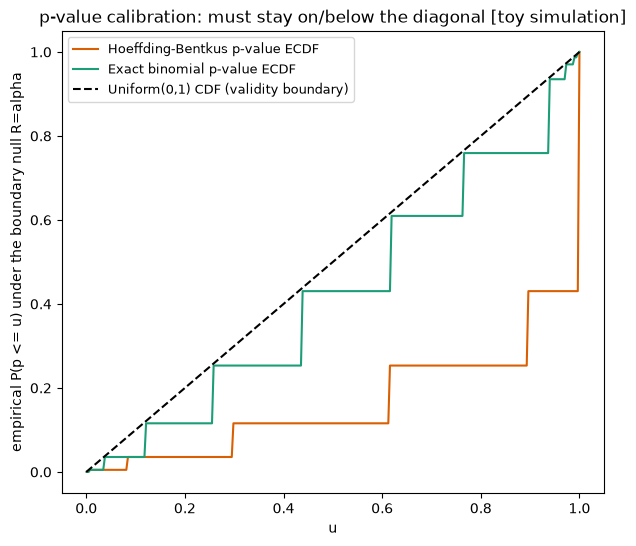

In [5]:
# VIZ
u_grid = np.linspace(0.001, 1, 300)
ecdf_hb = np.array([(p_hb_null <= u).mean() for u in u_grid])
ecdf_bin = np.array([(p_bin_null <= u).mean() for u in u_grid])

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(u_grid, ecdf_hb, color=PALETTE["crc"], label="Hoeffding-Bentkus p-value ECDF")
ax.plot(u_grid, ecdf_bin, color=PALETTE["ltt"], label="Exact binomial p-value ECDF")
ax.plot([0, 1], [0, 1], color=PALETTE["target"], linestyle="--", label="Uniform(0,1) CDF (validity boundary)")
ax.set_xlabel("u")
ax.set_ylabel("empirical P(p <= u) under the boundary null R=alpha")
ax.set_title("p-value calibration: must stay on/below the diagonal [toy simulation]")
ax.legend(fontsize=9)
plt.show()

### 2b. FWER control: Bonferroni vs. fixed sequence vs. multi-start

**Derived-here toy setup** to exercise Algorithm 1: `X ~ Uniform(0,1)`, `lambda` grid over `[0,1]`,
binary loss `L(lambda) = 1{X > lambda}`, so the true risk `R(lambda) = 1-lambda` is exactly linear and
non-increasing in lambda — the "monotone risk curve on a grid" the brief asks for. Null
`H_j: R(lambda_j) > alpha` is true exactly for `lambda_j < 1-alpha`. All three procedures below use the
**same exact binomial p-values** `[P1 Sec. 3.2, facered-q2]`; what differs is only how many hypotheses
are tested and at what level, per **Algorithm 1** `[P1, facered-q2]`.

The FWER event — "some accepted λ actually has risk > α" — is, by monotonicity, exactly
"the *smallest* accepted λ is < 1−α" (an accepted set with any bad member always includes the smallest
one being bad, since risk is non-increasing in λ).

In [6]:
def multistart_fixed_sequence(p_matrix, delta, starts):
    # Algorithm 1 [P1, facered-q2], vectorized over Monte Carlo replicates.
    # p_matrix: (M, N) p-values, columns ordered from safest (index 0) to riskiest (index N-1).
    # starts: list of column indices to initialize independent forward walks from.
    # Each walk tests at level delta/|starts|, walking forward (increasing index) while p<=thresh,
    # stopping at the first failure; Lambda_hat is the union of all walks' accepted indices.
    M, N = p_matrix.shape
    J = len(starts)
    thresh = delta / J
    bad = p_matrix > thresh
    idx = np.arange(N)[None, :]
    accept = np.zeros((M, N), dtype=bool)
    for s in starts:
        seg = bad[:, s:]
        any_bad = seg.any(axis=1)
        first_bad_rel = np.argmax(seg, axis=1)
        run_len = np.where(any_bad, first_bad_rel, N - s)
        accept |= (idx >= s) & (idx < (s + run_len[:, None]))
    return accept


rng_2b = np.random.default_rng(RNG_SEED + 3)
n_2b, alpha_2b, delta_2b = 150, 0.10, 0.10
N_grid_2b = 50
M_2b = 3000
lam_desc_2b = np.linspace(1.0, 0.0, N_grid_2b)   # index 0 = safest (lambda=1), index N-1 = riskiest
bad_lambda_2b = lam_desc_2b < (1 - alpha_2b)      # True risk of this lambda exceeds alpha

X_2b = rng_2b.uniform(0, 1, size=(M_2b, n_2b))
# Rhat(lambda) = P(X > lambda) empirical, evaluated at the descending grid directly.
Rhat_2b = (X_2b[:, :, None] > lam_desc_2b[None, None, :]).mean(axis=1)  # (M, N)
p_2b = stats.binom.cdf(np.ceil(n_2b * Rhat_2b), n_2b, alpha_2b)          # (M, N)

# Bonferroni: reject H_j if p_j <= delta/N, for every j independently.
bonf_accept = p_2b <= (delta_2b / N_grid_2b)
# Single fixed-sequence: one walk from the safest point, full level delta.
fixseq_accept = multistart_fixed_sequence(p_2b, delta_2b, starts=[0])
# Multi-start: J=5 walks spread across the grid, each at level delta/J.
starts_multi = [0, N_grid_2b // 5, 2 * N_grid_2b // 5, 3 * N_grid_2b // 5, 4 * N_grid_2b // 5]
multistart_accept_arr = multistart_fixed_sequence(p_2b, delta_2b, starts=starts_multi)

def fwer_and_size(accept_mask):
    violation = (accept_mask & bad_lambda_2b[None, :]).any(axis=1)
    return violation.mean(), accept_mask.sum(axis=1).mean()

fwer_bonf, size_bonf = fwer_and_size(bonf_accept)
fwer_fixseq, size_fixseq = fwer_and_size(fixseq_accept)
fwer_multi, size_multi = fwer_and_size(multistart_accept_arr)

tol_2b = 3 * np.sqrt(delta_2b * (1 - delta_2b) / M_2b)
print(f"Monte Carlo FWER over {M_2b} replicate calibration draws, n={n_2b}, alpha={alpha_2b}, delta={delta_2b}:")
for name, fwer, size in [("Bonferroni", fwer_bonf, size_bonf),
                          ("Fixed sequence (single start)", fwer_fixseq, size_fixseq),
                          ("Multi-start (J=5, delta/J)", fwer_multi, size_multi)]:
    ok = fwer <= delta_2b + tol_2b
    print(f"  {name:<32} FWER={fwer:.4f} (<=delta+tol={delta_2b+tol_2b:.4f}) {'PASS' if ok else 'FAIL'}   "
          f"mean |Lambda_hat|={size:.2f}")

print(f"CHECK 2.3: Bonferroni FWER <= delta+tol -> {'PASS' if fwer_bonf <= delta_2b+tol_2b else 'FAIL'}")
print(f"CHECK 2.4: fixed-sequence FWER <= delta+tol -> {'PASS' if fwer_fixseq <= delta_2b+tol_2b else 'FAIL'}")
print(f"CHECK 2.5: multi-start FWER <= delta+tol -> {'PASS' if fwer_multi <= delta_2b+tol_2b else 'FAIL'}")
print(f"CHECK 2.6: fixed-sequence rejects more than Bonferroni on average "
      f"({size_fixseq:.2f} > {size_bonf:.2f}) -> {'PASS' if size_fixseq > size_bonf else 'FAIL'}")

Monte Carlo FWER over 3000 replicate calibration draws, n=150, alpha=0.1, delta=0.1:
  Bonferroni                       FWER=0.0013 (<=delta+tol=0.1164) PASS   mean |Lambda_hat|=2.46
  Fixed sequence (single start)    FWER=0.0443 (<=delta+tol=0.1164) PASS   mean |Lambda_hat|=3.74
  Multi-start (J=5, delta/J)       FWER=0.0117 (<=delta+tol=0.1164) PASS   mean |Lambda_hat|=3.10
CHECK 2.3: Bonferroni FWER <= delta+tol -> PASS
CHECK 2.4: fixed-sequence FWER <= delta+tol -> PASS
CHECK 2.5: multi-start FWER <= delta+tol -> PASS
CHECK 2.6: fixed-sequence rejects more than Bonferroni on average (3.74 > 2.46) -> PASS


#### How to read this chart

Left: FWER (fraction of the 3,000 replicate calibration draws in which **some** accepted λ actually
violates the target) for the three procedures, black dashed line at δ=0.10 — all three bars must sit at
or below the line. Right: mean size of the accepted set `|Λ̂|` for the same three procedures — this is
the **power** comparison the brief asks for. Bonferroni pays a `1/N` penalty on every single grid point
and is typically the most conservative (smallest `|Λ̂|`); the fixed-sequence walk, by testing at the
full level δ along a single monotone path, recovers far more of the valid region for the same δ budget.
For the face-redaction CLI this is the concrete reason a monotone grid over threshold/padding/margin
should be tested with a fixed sequence rather than a blanket Bonferroni correction whenever the risk
curve is known to be monotone.

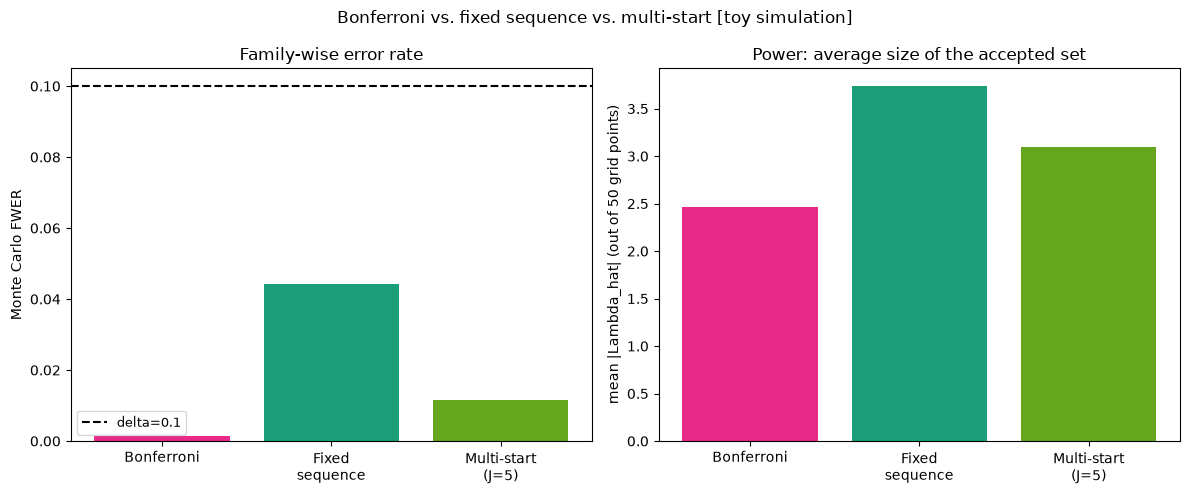

In [7]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
names = ["Bonferroni", "Fixed\nsequence", "Multi-start\n(J=5)"]
fwers = [fwer_bonf, fwer_fixseq, fwer_multi]
sizes = [size_bonf, size_fixseq, size_multi]
colors_2b = [PALETTE["bad"], PALETTE["ltt"], PALETTE["aux"]]

axes[0].bar(names, fwers, color=colors_2b)
axes[0].axhline(delta_2b, color=PALETTE["target"], linestyle="--", label=f"delta={delta_2b}")
axes[0].set_ylabel("Monte Carlo FWER")
axes[0].set_title("Family-wise error rate")
axes[0].legend(fontsize=9)

axes[1].bar(names, sizes, color=colors_2b)
axes[1].set_ylabel("mean |Lambda_hat| (out of 50 grid points)")
axes[1].set_title("Power: average size of the accepted set")
fig.suptitle("Bonferroni vs. fixed sequence vs. multi-start [toy simulation]")
plt.tight_layout()
plt.show()

### 2c. Multiple risks jointly: recall and false-blur on a 2-D grid

**Derived-here toy setup**, mapped onto the client's own two targets: `lambda1` controls a *miss-rate*
loss `R1(lambda1) = 1-lambda1` and `lambda2` an independent *false-blur-rate* loss
`R2(lambda2) = 1-lambda2` (both non-increasing in their own coordinate, by the same Uniform-threshold
construction as §2b, driven by two independent synthetic score streams). Prop. 6's max-p-value
combination `[P1, facered-q2]` lets a single Bonferroni pass over the *joint* grid certify **both**
risks at once, at the *same* δ used for a single risk.

In [8]:
rng_2c = np.random.default_rng(RNG_SEED + 4)
n_2c = 800
alpha1_2c, alpha2_2c = 0.15, 0.15   # toy: miss-rate target and false-blur-rate target
delta_2c = 0.10
N1_2c, N2_2c = 10, 10
M_2c = 1500

lam1_2c = np.linspace(1.0, 0.0, N1_2c)  # descending: index 0 safest for risk 1
lam2_2c = np.linspace(1.0, 0.0, N2_2c)  # descending: index 0 safest for risk 2

X1_2c = rng_2c.uniform(0, 1, size=(M_2c, n_2c))
X2_2c = rng_2c.uniform(0, 1, size=(M_2c, n_2c))
Rhat1_2c = (X1_2c[:, :, None] > lam1_2c[None, None, :]).mean(axis=1)  # (M, N1)
Rhat2_2c = (X2_2c[:, :, None] > lam2_2c[None, None, :]).mean(axis=1)  # (M, N2)

p1_2c = stats.binom.cdf(np.ceil(n_2c * Rhat1_2c), n_2c, alpha1_2c)  # (M, N1)
p2_2c = stats.binom.cdf(np.ceil(n_2c * Rhat2_2c), n_2c, alpha2_2c)  # (M, N2)

# Prop. 6: p_j := max_l p_{j,l} is a valid p-value for the joint null [P1, facered-q2].
p_joint_2c = np.maximum(p1_2c[:, :, None], p2_2c[:, None, :])  # (M, N1, N2)
N_joint = N1_2c * N2_2c
accept_2c = p_joint_2c <= (delta_2c / N_joint)  # Bonferroni over the joint grid

# Ground truth: risk 1 <= alpha1 iff lambda1 >= 1-alpha1; risk 2 <= alpha2 iff lambda2 >= 1-alpha2.
bad1_2c = lam1_2c < (1 - alpha1_2c)              # (N1,)
bad2_2c = lam2_2c < (1 - alpha2_2c)              # (N2,)
violation_grid = bad1_2c[None, :, None] | bad2_2c[None, None, :]  # (1, N1, N2) broadcastable

any_violation_2c = (accept_2c & violation_grid).any(axis=(1, 2))  # (M,)
fwer_joint = any_violation_2c.mean()
tol_2c = 3 * np.sqrt(delta_2c * (1 - delta_2c) / M_2c)
mean_size_2c = accept_2c.sum(axis=(1, 2)).mean()

print(f"Monte Carlo joint FWER over {M_2c} replicate draws, n={n_2c}, "
      f"alpha1={alpha1_2c} (miss rate), alpha2={alpha2_2c} (false-blur rate), delta={delta_2c}:")
print(f"  joint FWER = {fwer_joint:.4f} (<=delta+tol={delta_2c+tol_2c:.4f})")
print(f"  mean size of jointly-certified grid region = {mean_size_2c:.2f} / {N_joint} points")
ok_2c = fwer_joint <= delta_2c + tol_2c
print(f"CHECK 2.7: joint FWER over the JOINT null (either risk violated) <= delta+tol "
      f"-> {'PASS' if ok_2c else 'FAIL'}")

# Frequency map for the heatmap: how often each grid point is accepted across the 1500 replicates.
accept_freq_2c = accept_2c.mean(axis=0)  # (N1, N2)

Monte Carlo joint FWER over 1500 replicate draws, n=800, alpha1=0.15 (miss rate), alpha2=0.15 (false-blur rate), delta=0.1:
  joint FWER = 0.0000 (<=delta+tol=0.1232)
  mean size of jointly-certified grid region = 2.42 / 100 points
CHECK 2.7: joint FWER over the JOINT null (either risk violated) <= delta+tol -> PASS


#### How to read this chart

A heatmap over the joint (λ1, λ2) grid: color is the Monte Carlo **acceptance frequency** (how often
that grid point lands in Λ̂ across the 1,500 replicate draws), and the two dashed lines mark the true
boundaries `λ1 = 1-α1` and `λ2 = 1-α2` — the truly-good region is the upper-right quadrant they carve
out. Acceptance frequency should be essentially zero outside that quadrant (confirming CHECK 2.7) and
can be well below 1 even inside it, since Prop. 6's max-p-value combination is conservative by
construction. For the face-redaction job this is the picture behind jointly certifying recall **and**
precision (or false-blur rate) from a *single* calibration pass with one shared δ, instead of stacking
two separate (α,δ)-guarantees and paying for each.

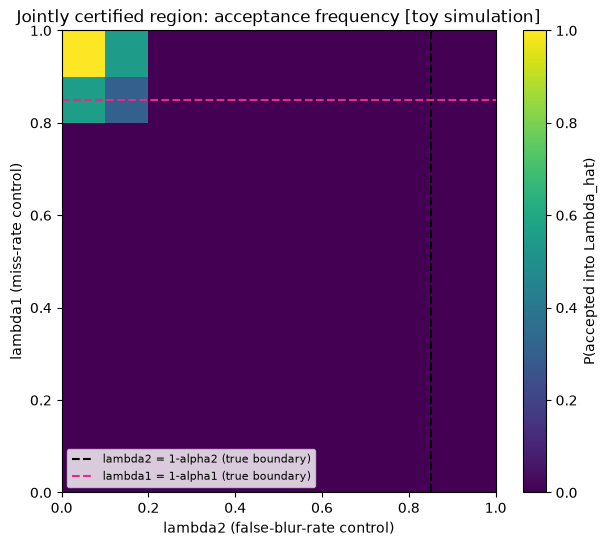

In [9]:
# VIZ
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(accept_freq_2c, origin="upper", aspect="auto",
               extent=[lam2_2c.min(), lam2_2c.max(), lam1_2c.min(), lam1_2c.max()],
               cmap="viridis", vmin=0, vmax=1)
ax.axvline(1 - alpha2_2c, color=PALETTE["target"], linestyle="--", label="lambda2 = 1-alpha2 (true boundary)")
ax.axhline(1 - alpha1_2c, color=PALETTE["bad"], linestyle="--", label="lambda1 = 1-alpha1 (true boundary)")
ax.set_xlabel("lambda2 (false-blur-rate control)")
ax.set_ylabel("lambda1 (miss-rate control)")
ax.set_title("Jointly certified region: acceptance frequency [toy simulation]")
ax.legend(fontsize=8, loc="lower left")
fig.colorbar(im, ax=ax, label="P(accepted into Lambda_hat)")
plt.show()

## 3. SeqCRC: two-step calibration, box margins, and the monotonization trick

SeqCRC calibrates a **confidence** threshold `λ_cnf` and a **localization** margin `λ_loc` in two
sequential steps `[P2 Eqs. 3-6, facered-q4]`:

> Eq. 3 (modified confidence risk): `R̃_n^cnf(λ_cnf) = max{ R_n^cnf(λ_cnf), R_n^loc(λ_cnf, λ̄_loc) }`
> (λ̄_loc = max Λ_loc). Eq. 4: `λ_cnf^+ = inf{λ_cnf : (n·R̃_n^cnf + B̃_cnf)/(n+1) ≤ α_cnf}`.
> Eq. 5: `λ_cnf^- = inf{λ_cnf : (n·R̃_n^cnf + 0)/(n+1) ≤ α_cnf}`.
> Eq. 6: `λ_loc^+ = inf{λ_loc : (n·R_n^loc(λ_cnf^-, λ_loc) + B_loc)/(n+1) ≤ α_loc}`.

The **losses** used here `[P2 Sec. IV, facered-q5]`:

> Box-count-recall (confidence): `L_cnf(λ_cnf) = (|y| - |Γ_cnf(λ_cnf)(x)|)_+ / |y|`.
> Box-wise recall (Eq. 14, localization): `L_loc(λ_cnf,λ_loc) = 1 - |{b_j ∈ y : b_j ⊆ b̂_π(j)^λloc}| / |y|`.
> Multiplicative margin (Eq. 13): `Γ_loc(x)_k = b̂_k + λ_loc·(-ŵ_k,-ĥ_k,ŵ_k,ĥ_k)`.

**Matching (derived here, simplified):** the paper uses a Hausdorff/LAC/mix matching cost
`[P2 Sec. IV-A, facered-q5]`; this notebook uses **nearest-centre matching** among the confidence-kept
candidates for each ground-truth box — simpler than the paper's Hausdorff-based scheme, stated
explicitly so the simplification is visible.

**Monotonization trick (derived here, following the paper's description):**
`[P2 Sec. III-B3, facered-q4]`: "the matching required for their computation is the root of this issue
… we propose a simple monotonization trick: within (4), (5), and (6) we replace `L_i^loc` … with the
smallest upper bounds that are provably monotone." The smallest non-increasing function that upper-bounds
a (possibly non-monotone) curve `f(λ)` is its **running maximum from the right**:
`f_mono(λ_j) = max_{j' ≥ j} f(λ_j')`. We implement exactly this (`np.maximum.accumulate` on the
reversed curve) wherever a localization-loss curve is scanned across `λ_cnf`.

In [10]:
# Toy detector simulator (derived here). Each image has 0-3 ground-truth face boxes; each GT box
# gets TWO candidate detections: a well-localized "primary" candidate, and a "decoy" candidate whose
# centre sits CLOSER to the GT centre (so nearest-centre matching prefers it once it clears the
# confidence threshold) but whose box size is noisier. This creates a genuine matching SHIFT as
# lambda_cnf grows and the decoy becomes admissible -- the mechanism Remark 1 [P2, facered-q5]
# describes -- which is what the monotonization trick exists to fix.
max_boxes_s3 = 3
box_count_probs_s3 = np.array([0.35, 0.30, 0.20, 0.15])  # P(k=0,1,2,3 GT boxes)


def simulate_images(n_images, rng_local):
    k = rng_local.choice(4, size=n_images, p=box_count_probs_s3)
    valid = (np.arange(max_boxes_s3)[None, :] < k[:, None])

    gt_w = rng_local.uniform(8, 20, size=(n_images, max_boxes_s3))
    gt_h = rng_local.uniform(8, 20, size=(n_images, max_boxes_s3))
    gt_cx = rng_local.uniform(20, 80, size=(n_images, max_boxes_s3))
    gt_cy = rng_local.uniform(20, 80, size=(n_images, max_boxes_s3))

    score_p = rng_local.beta(5, 1.5, size=(n_images, max_boxes_s3))
    score_d = score_p * rng_local.uniform(0.5, 0.95, size=(n_images, max_boxes_s3))

    off_p_x = rng_local.normal(0, 0.15, size=(n_images, max_boxes_s3)) * gt_w
    off_p_y = rng_local.normal(0, 0.15, size=(n_images, max_boxes_s3)) * gt_h
    off_d_x = rng_local.normal(0, 0.02, size=(n_images, max_boxes_s3)) * gt_w
    off_d_y = rng_local.normal(0, 0.02, size=(n_images, max_boxes_s3)) * gt_h

    szn_p_w = rng_local.lognormal(0, 0.10, size=(n_images, max_boxes_s3))
    szn_p_h = rng_local.lognormal(0, 0.10, size=(n_images, max_boxes_s3))
    szn_d_w = rng_local.lognormal(0, 0.40, size=(n_images, max_boxes_s3))
    szn_d_h = rng_local.lognormal(0, 0.40, size=(n_images, max_boxes_s3))

    return dict(
        valid=valid, k=k,
        gt_cx=gt_cx, gt_cy=gt_cy, gt_w=gt_w, gt_h=gt_h,
        score_p=score_p, score_d=score_d,
        pred_p_cx=gt_cx + off_p_x, pred_p_cy=gt_cy + off_p_y,
        pred_p_w=gt_w * szn_p_w, pred_p_h=gt_h * szn_p_h,
        pred_d_cx=gt_cx + off_d_x, pred_d_cy=gt_cy + off_d_y,
        pred_d_w=gt_w * szn_d_w, pred_d_h=gt_h * szn_d_h,
        dist_p=np.hypot(off_p_x, off_p_y), dist_d=np.hypot(off_d_x, off_d_y),
    )


def compute_losses(img, lambda_cnf, lambda_loc):
    # Nearest-centre matching among confidence-kept candidates (derived here, simplified vs. the
    # paper's Hausdorff/LAC/mix matching [P2 Sec. IV-A, facered-q5]).
    thr = 1 - lambda_cnf
    kept_p = img["valid"] & (img["score_p"] >= thr)
    kept_d = img["valid"] & (img["score_d"] >= thr)
    prefer_d = kept_d & (~kept_p | (img["dist_d"] <= img["dist_p"]))
    use_p = kept_p & ~prefer_d
    use_d = kept_d & prefer_d
    matched_any = use_p | use_d

    mcx = np.where(use_p, img["pred_p_cx"], img["pred_d_cx"])
    mcy = np.where(use_p, img["pred_p_cy"], img["pred_d_cy"])
    mw = np.where(use_p, img["pred_p_w"], img["pred_d_w"])
    mh = np.where(use_p, img["pred_p_h"], img["pred_d_h"])

    # Multiplicative margin, Eq. 13 [P2, facered-q5].
    left = mcx - mw / 2 - lambda_loc * mw
    right = mcx + mw / 2 + lambda_loc * mw
    top = mcy - mh / 2 - lambda_loc * mh
    bot = mcy + mh / 2 + lambda_loc * mh

    gt_left = img["gt_cx"] - img["gt_w"] / 2
    gt_right = img["gt_cx"] + img["gt_w"] / 2
    gt_top = img["gt_cy"] - img["gt_h"] / 2
    gt_bot = img["gt_cy"] + img["gt_h"] / 2

    covered = matched_any & (gt_left >= left) & (gt_right <= right) & (gt_top >= top) & (gt_bot <= bot)
    covered = covered & img["valid"]

    n_kept_img = (kept_p & img["valid"]).sum(axis=1) + (kept_d & img["valid"]).sum(axis=1)
    k_img = img["k"]
    L_cnf_img = np.where(k_img > 0, np.maximum(0, k_img - n_kept_img) / np.maximum(k_img, 1), 0.0)

    covered_count = covered.sum(axis=1)
    L_loc_img = np.where(k_img > 0, 1 - covered_count / np.maximum(k_img, 1), 0.0)
    return L_cnf_img, L_loc_img


print("Simulator and loss functions defined (box-count-recall confidence loss, box-wise recall "
      "localization loss [P2 Eq. 14, facered-q5], nearest-centre matching, multiplicative margin "
      "[P2 Eq. 13, facered-q5]).")

Simulator and loss functions defined (box-count-recall confidence loss, box-wise recall localization loss [P2 Eq. 14, facered-q5], nearest-centre matching, multiplicative margin [P2 Eq. 13, facered-q5]).


In [11]:
def monotonize_from_right(curve):
    # Smallest non-increasing upper bound = running max from the right (derived here, following
    # the paper's description of the monotonization trick [P2 Sec. III-B3, facered-q4]).
    return np.maximum.accumulate(curve[::-1])[::-1]


def two_step_calibration(img_cal, n_cal, lam_cnf_grid, lam_loc_grid, alpha_cnf, alpha_loc, B=1.0):
    # Step 1 (Eq. 3-5): scan lambda_cnf at lambda_loc = max(Lambda_loc).
    lam_loc_max = lam_loc_grid.max()
    R_cnf = np.array([compute_losses(img_cal, lc, lam_loc_max)[0].mean() for lc in lam_cnf_grid])
    R_loc_at_max = np.array([compute_losses(img_cal, lc, lam_loc_max)[1].mean() for lc in lam_cnf_grid])
    n_nonmono = int((np.diff(R_loc_at_max) > 1e-12).sum())  # count of upward jumps = non-monotone points
    R_loc_at_max_mono = monotonize_from_right(R_loc_at_max)

    R_tilde_cnf = np.maximum(R_cnf, R_loc_at_max_mono)  # Eq. 3
    lhs_plus = (n_cal * R_tilde_cnf + B) / (n_cal + 1)
    lhs_minus = (n_cal * R_tilde_cnf + 0.0) / (n_cal + 1)

    ok_plus = lhs_plus <= alpha_cnf
    lam_cnf_plus = lam_cnf_grid[np.argmax(ok_plus)] if ok_plus.any() else lam_cnf_grid.max()
    ok_minus = lhs_minus <= alpha_cnf
    lam_cnf_minus = lam_cnf_grid[np.argmax(ok_minus)] if ok_minus.any() else lam_cnf_grid.max()

    # Step 2 (Eq. 6): scan lambda_loc at the fixed lambda_cnf^-.
    R_loc_scan = np.array([compute_losses(img_cal, lam_cnf_minus, ll)[1].mean() for ll in lam_loc_grid])
    R_loc_scan_mono = monotonize_from_right(R_loc_scan)  # no-op here in expectation (already monotone)
    lhs_loc = (n_cal * R_loc_scan_mono + B) / (n_cal + 1)
    ok_loc = lhs_loc <= alpha_loc
    lam_loc_plus = lam_loc_grid[np.argmax(ok_loc)] if ok_loc.any() else lam_loc_grid.max()

    return lam_cnf_plus, lam_cnf_minus, lam_loc_plus, n_nonmono


n_cal_s3 = 250
lam_cnf_grid_s3 = np.linspace(0.0, 1.0, 61)
lam_loc_grid_s3 = np.linspace(0.0, 0.4, 51)
alpha_cnf_s3, alpha_loc_s3 = 0.10, 0.20
lam_loc_max_s3 = lam_loc_grid_s3.max()

# Diagnostic + illustrative calibration on one realistic-size calibration draw (n=250): does
# R_loc(lambda_cnf, max margin) actually dip as lambda_cnf grows, from the primary->decoy matching
# switch [Remark 1, P2, facered-q5]?
rng_3 = np.random.default_rng(RNG_SEED + 5)
img_demo = simulate_images(n_cal_s3, rng_3)
R_loc_at_max_demo = np.array([compute_losses(img_demo, lc, lam_loc_max_s3)[1].mean()
                               for lc in lam_cnf_grid_s3])
n_nonmono_demo = int((np.diff(R_loc_at_max_demo) > 1e-9).sum())
mono_demo = monotonize_from_right(R_loc_at_max_demo)
is_mono_demo = np.all(np.diff(mono_demo) <= 1e-9)
print(f"Diagnostic (n={n_cal_s3}, margin capped at {lam_loc_max_s3}): {n_nonmono_demo} upward "
      f"(non-monotone) jumps in the raw R_loc(lambda_cnf, max margin) curve before monotonization.")
print("These come from the primary->decoy matching switch [Remark 1, P2, facered-q5] plus ordinary "
      "sampling noise at this calibration-set size -- both are exactly why the trick is needed.")
print(f"CHECK 3.1: the monotonized curve (running max from the right) is non-increasing by construction "
      f"-> {'PASS' if is_mono_demo else 'FAIL'}")

lcp_demo, lcm_demo, llp_demo, _ = two_step_calibration(
    img_demo, n_cal_s3, lam_cnf_grid_s3, lam_loc_grid_s3, alpha_cnf_s3, alpha_loc_s3)
print(f"\nIllustrative calibration draw (n={n_cal_s3}): lambda_cnf+={lcp_demo:.3f}, "
      f"lambda_cnf-={lcm_demo:.3f}, lambda_loc+={llp_demo:.3f}")

Diagnostic (n=250, margin capped at 0.4): 10 upward (non-monotone) jumps in the raw R_loc(lambda_cnf, max margin) curve before monotonization.
These come from the primary->decoy matching switch [Remark 1, P2, facered-q5] plus ordinary sampling noise at this calibration-set size -- both are exactly why the trick is needed.
CHECK 3.1: the monotonized curve (running max from the right) is non-increasing by construction -> PASS

Illustrative calibration draw (n=250): lambda_cnf+=1.000, lambda_cnf-=1.000, lambda_loc+=0.288


**On false positives / precision** `[P2 Sec. V-D, facered-q5, facered-q6]`:

> "First, our approach guarantees a large enough recall but only empirically limits false positives
> (via the confidence thresholding step). In fact, precision is a non-monotone function of its
> parameters, and monotonizing it using our approach could lead to too large risks for a solution to
> exist."

So we do **not** compute a precision check here — SeqCRC gives none to check. Only `E[L_test^loc] ≤
α_loc` (Eq. 7) is checked below, via many independent calibration draws against a fixed held-out test
pool, following the paper's own **in-expectation** language `[facered-q4]`.

In [12]:
rng_pool = np.random.default_rng(RNG_SEED + 7)
test_pool_s3 = simulate_images(6000, rng_pool)  # fixed held-out test pool, independent of every draw

D_s3 = 400
rng_draws_s3 = np.random.default_rng(RNG_SEED + 8)
test_risks_s3 = np.empty(D_s3)
for d in range(D_s3):
    img_cal_d = simulate_images(n_cal_s3, rng_draws_s3)
    lcp, lcm, llp, _ = two_step_calibration(
        img_cal_d, n_cal_s3, lam_cnf_grid_s3, lam_loc_grid_s3, alpha_cnf_s3, alpha_loc_s3)
    test_risks_s3[d] = compute_losses(test_pool_s3, lcp, llp)[1].mean()

mean_test_risk_s3 = test_risks_s3.mean()
frac_violate_s3 = (test_risks_s3 > alpha_loc_s3).mean()

print(f"Monte Carlo over {D_s3} independent calibration draws (n={n_cal_s3} each), "
      f"evaluated on one shared test pool (n_test=6000):")
print(f"  mean E[L_test^loc] estimate = {mean_test_risk_s3:.4f}  (target alpha_loc={alpha_loc_s3})")
print(f"  per-draw violation fraction (test risk > alpha_loc) = {frac_violate_s3:.3f}  "
      f"[not guaranteed small by Theorem 2 -- it is an expectation bound, per Sec. 1]")
print(f"CHECK 3.2: mean E[L_test^loc] <= alpha_loc "
      f"-> {'PASS' if mean_test_risk_s3 <= alpha_loc_s3 else 'FAIL'}")

# Smaller sweep across several alpha_loc targets, to plot mean risk and violation fraction vs alpha.
alpha_sweep_s3 = np.array([0.15, 0.20, 0.25, 0.30, 0.40])
D_sweep_s3 = 120
mean_risk_sweep = np.empty(len(alpha_sweep_s3))
viol_frac_sweep = np.empty(len(alpha_sweep_s3))
rng_sweep_s3 = np.random.default_rng(RNG_SEED + 10)
for i, a_loc in enumerate(alpha_sweep_s3):
    risks_i = np.empty(D_sweep_s3)
    for d in range(D_sweep_s3):
        img_cal_i = simulate_images(n_cal_s3, rng_sweep_s3)
        lcp, lcm, llp, _ = two_step_calibration(
            img_cal_i, n_cal_s3, lam_cnf_grid_s3, lam_loc_grid_s3, alpha_cnf_s3, a_loc)
        risks_i[d] = compute_losses(test_pool_s3, lcp, llp)[1].mean()
    mean_risk_sweep[i] = risks_i.mean()
    viol_frac_sweep[i] = (risks_i > a_loc).mean()
print("\nSweep across alpha_loc (D=120 draws each):")
for a, m, v in zip(alpha_sweep_s3, mean_risk_sweep, viol_frac_sweep):
    print(f"  alpha_loc={a:.2f}: mean risk={m:.4f} ({'<=' if m<=a else '>'} target), "
          f"violation fraction={v:.3f}")

Monte Carlo over 400 independent calibration draws (n=250 each), evaluated on one shared test pool (n_test=6000):
  mean E[L_test^loc] estimate = 0.1946  (target alpha_loc=0.2)
  per-draw violation fraction (test risk > alpha_loc) = 0.338  [not guaranteed small by Theorem 2 -- it is an expectation bound, per Sec. 1]
CHECK 3.2: mean E[L_test^loc] <= alpha_loc -> PASS



Sweep across alpha_loc (D=120 draws each):
  alpha_loc=0.15: mean risk=0.1469 (<= target), violation fraction=0.450
  alpha_loc=0.20: mean risk=0.1956 (<= target), violation fraction=0.367
  alpha_loc=0.25: mean risk=0.2427 (<= target), violation fraction=0.383
  alpha_loc=0.30: mean risk=0.2920 (<= target), violation fraction=0.400
  alpha_loc=0.40: mean risk=0.3775 (<= target), violation fraction=0.200


#### How to read this chart

Left: mean test-time localization risk (teal points, from the α_loc sweep) against the toy target
values, black dashed reference line at y=x — points should sit at or below the line (mean risk
controlled, by Theorem 2). Right: the per-draw violation fraction at each α_loc (magenta bars) — this is
explicitly **not** guaranteed to be small by SeqCRC's guarantee (only the *mean* is controlled), and the
brief predicts it will not be. For the face-redaction job this is the direct evidence for why SeqCRC
alone cannot be the *final* decision rule: a fixed, non-trivial fraction of calibration runs land above
target even when the average across runs is fine.

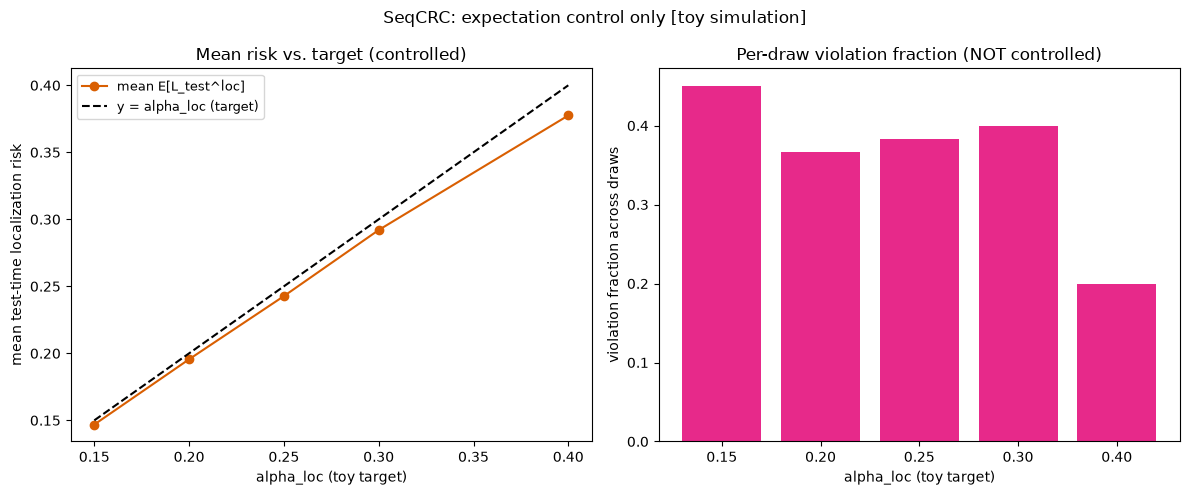

In [13]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(alpha_sweep_s3, mean_risk_sweep, "o-", color=PALETTE["crc"], label="mean E[L_test^loc]")
axes[0].plot(alpha_sweep_s3, alpha_sweep_s3, "--", color=PALETTE["target"], label="y = alpha_loc (target)")
axes[0].set_xlabel("alpha_loc (toy target)")
axes[0].set_ylabel("mean test-time localization risk")
axes[0].set_title("Mean risk vs. target (controlled)")
axes[0].legend(fontsize=9)

axes[1].bar([f"{a:.2f}" for a in alpha_sweep_s3], viol_frac_sweep, color=PALETTE["bad"])
axes[1].set_xlabel("alpha_loc (toy target)")
axes[1].set_ylabel("violation fraction across draws")
axes[1].set_title("Per-draw violation fraction (NOT controlled)")
fig.suptitle("SeqCRC: expectation control only [toy simulation]")
plt.tight_layout()
plt.show()

**Example image (derived here):** one calibration-set image with its ground-truth box, the raw
predicted box, and the multiplicative-margin-enlarged box, to make Eq. 13 `[P2, facered-q5]` concrete.

In [14]:
rng_ex = np.random.default_rng(RNG_SEED + 9)
img_ex = simulate_images(1, rng_ex)
# Force exactly one box for a clean illustration.
img_ex["valid"][:] = False
img_ex["valid"][0, 0] = True
img_ex["k"][:] = 1
lam_loc_example = 0.30

gt = (img_ex["gt_cx"][0, 0], img_ex["gt_cy"][0, 0], img_ex["gt_w"][0, 0], img_ex["gt_h"][0, 0])
pred = (img_ex["pred_p_cx"][0, 0], img_ex["pred_p_cy"][0, 0], img_ex["pred_p_w"][0, 0], img_ex["pred_p_h"][0, 0])
margin_left = pred[0] - pred[2] / 2 - lam_loc_example * pred[2]
margin_right = pred[0] + pred[2] / 2 + lam_loc_example * pred[2]
margin_top = pred[1] - pred[3] / 2 - lam_loc_example * pred[3]
margin_bot = pred[1] + pred[3] / 2 + lam_loc_example * pred[3]
print(f"Ground truth box: center=({gt[0]:.1f},{gt[1]:.1f}) size=({gt[2]:.1f}x{gt[3]:.1f})")
print(f"Raw prediction:   center=({pred[0]:.1f},{pred[1]:.1f}) size=({pred[2]:.1f}x{pred[3]:.1f})")
print(f"Margin-enlarged (lambda_loc={lam_loc_example}): "
      f"[{margin_left:.1f},{margin_top:.1f}] to [{margin_right:.1f},{margin_bot:.1f}]")

Ground truth box: center=(28.1,50.5) size=(17.9x19.7)
Raw prediction:   center=(28.3,48.9) size=(20.1x18.1)
Margin-enlarged (lambda_loc=0.3): [12.3,34.4] to [44.4,63.3]


#### How to read this chart

One synthetic image: the green rectangle is the ground-truth face box, the red rectangle is the raw
predicted box (before any margin), and the purple rectangle is the multiplicative-margin-enlarged
prediction (Eq. 13) that the localization loss actually checks containment against. The point of the
multiplicative (rather than additive) margin is visible directly: the enlargement is proportional to the
*predicted* box's own width and height, so a small face gets a small absolute margin and a large face
gets a large one.

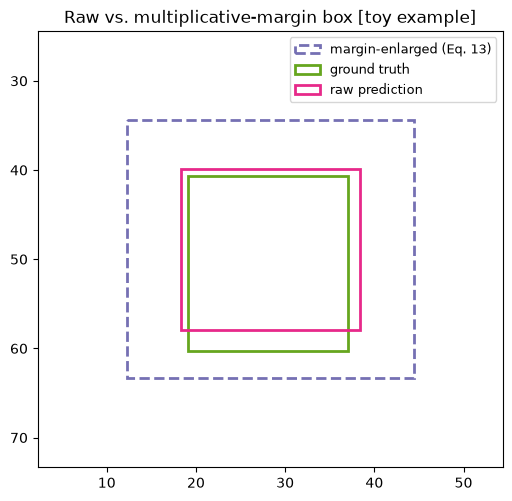

In [15]:
# VIZ
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6, 6))
gt_rect = patches.Rectangle((gt[0] - gt[2] / 2, gt[1] - gt[3] / 2), gt[2], gt[3],
                             linewidth=2, edgecolor=PALETTE["aux"], facecolor="none", label="ground truth")
pred_rect = patches.Rectangle((pred[0] - pred[2] / 2, pred[1] - pred[3] / 2), pred[2], pred[3],
                               linewidth=2, edgecolor=PALETTE["bad"], facecolor="none", label="raw prediction")
margin_rect = patches.Rectangle((margin_left, margin_top), margin_right - margin_left, margin_bot - margin_top,
                                 linewidth=2, edgecolor=PALETTE["cert"], facecolor="none", linestyle="--",
                                 label="margin-enlarged (Eq. 13)")
for r in (margin_rect, gt_rect, pred_rect):
    ax.add_patch(r)
all_x = [gt[0] - gt[2] / 2, gt[0] + gt[2] / 2, margin_left, margin_right]
all_y = [gt[1] - gt[3] / 2, gt[1] + gt[3] / 2, margin_top, margin_bot]
pad = 10
ax.set_xlim(min(all_x) - pad, max(all_x) + pad)
ax.set_ylim(min(all_y) - pad, max(all_y) + pad)
ax.invert_yaxis()
ax.set_aspect("equal")
ax.set_title("Raw vs. multiplicative-margin box [toy example]")
ax.legend(fontsize=9, loc="upper right")
plt.show()

## 4. Units: face-free frames and clustered misses (derived here)

**Everything in this section is derived here** — none of the three papers models video, frame
dependence, or a per-image-vs-per-instance distinction directly, though P2 motivates part (a):

> "an image may contain no ground-truth objects (i.e., y is empty) … we set the loss to zero"
> `[P2 Sec. IV-E, facered-q6]`.

and the assumptions-under-stress sweep confirms the gap: "**Not Stated:** Video frame sequences or
temporal tracking dependencies are **not** stated or modeled" by any of the three papers `[facered-q11]`.

**(a) Face-free frames dilute a per-image average.** If a SeqCRC-style loss is 0 on every frame with no
ground-truth face, and the client's footage is mostly face-free (whole episodes can have zero faces),
then the *per-image-averaged* risk shrinks proportionally to face prevalence π even while the
*per-instance* miss rate — what the client actually cares about — stays fixed. A per-image α target is
not a per-instance recall guarantee.

**(b) Misses cluster within a face track.** Frames belonging to the same face instance are temporally
dependent (motion blur, an occlusion, a turned head persist across several consecutive frames). Treating
individual frames as i.i.d. when computing a Clopper–Pearson bound on the per-frame miss rate — ignoring
this clustering — **under-covers** the true parameter. Treating **tracks** as the unit restores i.i.d.-ness
and valid coverage `[P3 Sec. 4, facered-q7]` machinery reused with an honestly-chosen unit of analysis.

In [16]:
# (a) Face-free frames dilute a per-image average (derived here).
rng_4a = np.random.default_rng(RNG_SEED + 11)
p_miss_instance = 0.10   # fixed per-face-instance miss probability, independent of prevalence
prevalences = np.array([0.5, 0.3, 0.1, 0.05, 0.01, 0.005])
N_img_4a = 400_000

image_avg_loss = np.empty(len(prevalences))
instance_miss_rate = np.empty(len(prevalences))
for i, pi in enumerate(prevalences):
    has_face = rng_4a.uniform(size=N_img_4a) < pi
    missed = rng_4a.uniform(size=N_img_4a) < p_miss_instance
    per_image_loss = np.where(has_face, missed.astype(float), 0.0)
    image_avg_loss[i] = per_image_loss.mean()
    instance_miss_rate[i] = missed[has_face].mean()

print("Per-image averaged loss shrinks with prevalence; per-instance miss rate does not:")
print(f"{'prevalence':>10} {'image-avg loss':>15} {'analytic pi*p_miss':>20} {'instance miss rate':>20}")
ok_a1, ok_a2 = True, True
for pi, avg, inst in zip(prevalences, image_avg_loss, instance_miss_rate):
    analytic = pi * p_miss_instance
    print(f"{pi:>10.3f} {avg:>15.5f} {analytic:>20.5f} {inst:>20.4f}")
    ok_a1 &= abs(avg - analytic) < 0.003
    ok_a2 &= abs(inst - p_miss_instance) < 0.01
print(f"CHECK 4.1: image-averaged loss matches analytic pi*p_miss within MC tolerance for all pi "
      f"-> {'PASS' if ok_a1 else 'FAIL'}")
print(f"CHECK 4.2: per-instance miss rate stays within tolerance of {p_miss_instance} regardless of pi "
      f"-> {'PASS' if ok_a2 else 'FAIL'}")

Per-image averaged loss shrinks with prevalence; per-instance miss rate does not:
prevalence  image-avg loss   analytic pi*p_miss   instance miss rate
     0.500         0.05001              0.05000               0.0999
     0.300         0.02998              0.03000               0.0997
     0.100         0.01005              0.01000               0.1009
     0.050         0.00508              0.00500               0.1021
     0.010         0.00092              0.00100               0.0921
     0.005         0.00051              0.00050               0.0998
CHECK 4.1: image-averaged loss matches analytic pi*p_miss within MC tolerance for all pi -> PASS
CHECK 4.2: per-instance miss rate stays within tolerance of 0.1 regardless of pi -> PASS


#### How to read this chart

Two curves vs. prevalence π (log x-axis): the per-image averaged loss (orange, ∝ π) collapses toward
zero as faces get rarer, while the per-face-instance miss rate (green, flat) stays at the fixed 10% used
to generate the data. For the face-redaction job: an SeqCRC/LTT risk target set on a **per-image**
average will look easily satisfied on face-sparse footage even while the **per-instance** recall the
client actually needs is unchanged — this is why every risk and every certificate downstream must be
defined **per face instance**, not per frame.

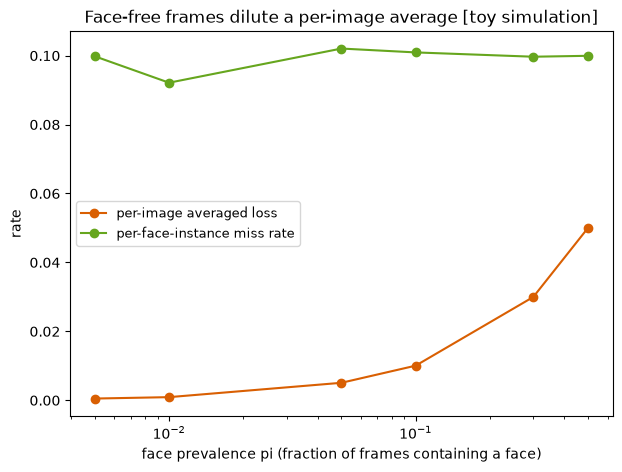

In [17]:
# VIZ
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prevalences, image_avg_loss, "o-", color=PALETTE["crc"], label="per-image averaged loss")
ax.plot(prevalences, instance_miss_rate, "o-", color=PALETTE["aux"], label="per-face-instance miss rate")
ax.set_xscale("log")
ax.set_xlabel("face prevalence pi (fraction of frames containing a face)")
ax.set_ylabel("rate")
ax.set_title("Face-free frames dilute a per-image average [toy simulation]")
ax.legend(fontsize=9)
plt.show()

### 4b. Clustered misses within a face track (derived here)

Face tracks last ~30–300 frames; per-frame detectability is simulated as a stationary AR(1) latent
process (correlation ρ=0.85) thresholded to give a fixed marginal per-frame miss probability. Two 95%
Clopper–Pearson upper bounds `[P3 Sec. 4, facered-q7]` are computed for the **same** underlying
per-frame miss parameter: one **wrong** (pooling all frames from all tracks as if i.i.d.), one
**correct** (one randomly selected frame per track — by construction i.i.d. across tracks, since a
single representative frame per track removes all intra-track correlation).

In [18]:
rng_4b = np.random.default_rng(RNG_SEED + 12)
M_rep_4b = 400          # Monte Carlo replicate audits
T_tracks_4b = 200       # tracks per replicate audit
rho_4b = 0.85
p_target_4b = 0.05      # true per-frame miss probability
Lmin_4b, Lmax_4b = 30, 300
delta_4b = 0.05

L_4b = rng_4b.integers(Lmin_4b, Lmax_4b + 1, size=(M_rep_4b, T_tracks_4b))
z = rng_4b.normal(0, 1, size=(M_rep_4b, T_tracks_4b))  # stationary AR(1) initial state
z_thresh_4b = stats.norm.ppf(p_target_4b)
eps_std_4b = np.sqrt(1 - rho_4b ** 2)

miss_total_4b = np.zeros((M_rep_4b, T_tracks_4b), dtype=int)
any_miss_4b = np.zeros((M_rep_4b, T_tracks_4b), dtype=bool)
rep_frame_miss_4b = (z <= z_thresh_4b)  # representative frame = t=0 (i.i.d. across tracks/replicates)
miss_total_4b += rep_frame_miss_4b.astype(int)
any_miss_4b |= rep_frame_miss_4b

for t in range(1, Lmax_4b):
    z = rho_4b * z + eps_std_4b * rng_4b.normal(0, 1, size=(M_rep_4b, T_tracks_4b))
    active = t < L_4b
    is_miss = (z <= z_thresh_4b) & active
    miss_total_4b += is_miss.astype(int)
    any_miss_4b |= is_miss

# Frame-level (WRONG): pool all frames across all tracks as if i.i.d.
k_frame_4b = miss_total_4b.sum(axis=1)
n_frame_4b = L_4b.sum(axis=1)
U_frame_4b = clopper_pearson_upper(k_frame_4b, n_frame_4b, delta_4b)
coverage_frame_4b = (p_target_4b <= U_frame_4b).mean()

# Track-level (RIGHT): one representative frame per track -> genuinely i.i.d. Bernoulli(p_target).
k_track_4b = rep_frame_miss_4b.sum(axis=1)
U_track_4b = clopper_pearson_upper(k_track_4b, T_tracks_4b, delta_4b)
coverage_track_4b = (p_target_4b <= U_track_4b).mean()

tol_4b = 3 * np.sqrt(0.95 * 0.05 / M_rep_4b)
print(f"Monte Carlo coverage of a nominal-95% Clopper-Pearson upper bound on the true per-frame "
      f"miss rate p={p_target_4b}, over {M_rep_4b} replicate audits of {T_tracks_4b} tracks each:")
print(f"  frame-level (pooled, WRONG unit): coverage = {coverage_frame_4b:.4f}")
print(f"  track-level (one frame/track, RIGHT unit): coverage = {coverage_track_4b:.4f} "
      f"(target 0.95 +/- tol {tol_4b:.4f})")
print(f"CHECK 4.3: frame-level bound under-covers (coverage < 0.95) -- reporting the number honestly "
      f"-> {'PASS (under-coverage confirmed)' if coverage_frame_4b < 0.95 - tol_4b else 'FAIL (no under-coverage observed)'}")
print(f"CHECK 4.4: track-level bound achieves nominal coverage "
      f"-> {'PASS' if abs(coverage_track_4b - 0.95) <= tol_4b else 'FAIL'}")

# Strict instance-level (any-frame-missed) vs frame-level miss rate.
instance_level_rate_4b = any_miss_4b.mean()
frame_level_rate_4b = miss_total_4b.sum() / L_4b.sum()
print(f"\nStrict instance-level miss rate (>=1 frame missed in the track) = {instance_level_rate_4b:.4f}")
print(f"Frame-level miss rate (average per-frame)                         = {frame_level_rate_4b:.4f}")
print(f"CHECK 4.5: instance-level rate >> frame-level rate for tracks this long "
      f"-> {'PASS' if instance_level_rate_4b > frame_level_rate_4b else 'FAIL'}")

Monte Carlo coverage of a nominal-95% Clopper-Pearson upper bound on the true per-frame miss rate p=0.05, over 400 replicate audits of 200 tracks each:
  frame-level (pooled, WRONG unit): coverage = 0.7775
  track-level (one frame/track, RIGHT unit): coverage = 0.9725 (target 0.95 +/- tol 0.0327)
CHECK 4.3: frame-level bound under-covers (coverage < 0.95) -- reporting the number honestly -> PASS (under-coverage confirmed)
CHECK 4.4: track-level bound achieves nominal coverage -> PASS

Strict instance-level miss rate (>=1 frame missed in the track) = 0.8710
Frame-level miss rate (average per-frame)                         = 0.0503
CHECK 4.5: instance-level rate >> frame-level rate for tracks this long -> PASS


#### How to read this chart

Two bars: Monte Carlo empirical coverage of a nominal-95% Clopper–Pearson upper bound on the true
per-frame miss rate, computed the wrong way (frame-level, magenta) and the right way (track-level,
green), against the black dashed 95% target. The frame-level bar sits well below the line — pooling
correlated frames as if independent makes the interval too narrow, so it fails to cover the true
parameter far more often than the nominal 5% error rate allows. The track-level bar sits on the line.
For the face-redaction job: **any** Clopper–Pearson or hypergeometric certificate computed later in this
notebook (§5, §6) is only valid if the audited **unit is exchangeable** — for video that means the
track or the episode, never the raw frame.

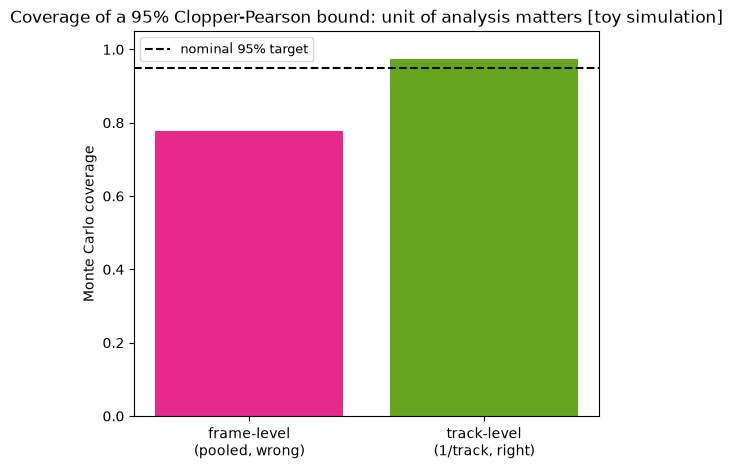

In [19]:
# VIZ
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["frame-level\n(pooled, wrong)", "track-level\n(1/track, right)"],
              [coverage_frame_4b, coverage_track_4b],
              color=[PALETTE["bad"], PALETTE["aux"]])
ax.axhline(0.95, color=PALETTE["target"], linestyle="--", label="nominal 95% target")
ax.set_ylabel("Monte Carlo coverage")
ax.set_ylim(0, 1.05)
ax.set_title("Coverage of a 95% Clopper-Pearson bound: unit of analysis matters [toy simulation]")
ax.legend(fontsize=9)
plt.show()

## 5. Audit certificates: Clopper–Pearson planning and the Sec. 8 worked example

**Zero-count planning formula** `[P3 Sec. 4.6, facered-q7, facered-q8]`:

> `n0 ≥ log(1/δ)/log(1/(1-ε))` … "Rule of three" `n0 ≈ 3/ε` at δ=0.05.

**Theorem 7 (excluded-pool binomial certificate)** `[P3, facered-q7]`:

> "with probability at least 1−δ, η(g) ≤ U_{n0}(K0(g), δ/|G|) and r(g) ≤ p0(g)·U_{n0}(K0(g), δ/|G|)."

**Theorem 8 (hypergeometric certificate)** and the **Sec. 8 worked example** `[P3, facered-q7,
facered-q8]`: N=100,000, N0=70,000, n0=300, δ0=0.025 → `U_300(0,0.025) ≈ 0.01222`, `r(g) ≤ 0.00856`;
exact hypergeometric `M_U=853`; K0=1→1,287; K0=2→1,668; n1=500, K1=100 → `M_L=4,983`,
`Recall(g) ≥ 0.8538`; whole-population audit ≈ 431 labels. We reproduce every one of these numbers
below, printed as **PAPER vs REPRODUCED**.

In [20]:
# Sec. 4.6 planning table, exact reproduction at delta=0.05.
def n0_planning(eps, delta):
    return int(np.ceil(np.log(1 / delta) / np.log(1 / (1 - eps))))

delta_plan = 0.05
eps_list = [0.10, 0.05, 0.02, 0.01, 0.005]
paper_single = [29, 59, 149, 299, 598]
paper_10pfx = [51, 104, 263, 528, 1058]

print(f"{'eps':>7} {'PAPER n0(1)':>12} {'REPRO n0(1)':>12} {'status':>8}   "
      f"{'PAPER n0(10)':>13} {'REPRO n0(10)':>13} {'status':>8}")
all_pass_plan = True
for eps, p1, p10 in zip(eps_list, paper_single, paper_10pfx):
    r1 = n0_planning(eps, delta_plan)
    r10 = n0_planning(eps, delta_plan / 10)
    ok1, ok10 = r1 == p1, r10 == p10
    all_pass_plan &= ok1 and ok10
    print(f"{eps:>7.3f} {p1:>12} {r1:>12} {'PASS' if ok1 else 'FAIL':>8}   "
          f"{p10:>13} {r10:>13} {'PASS' if ok10 else 'FAIL':>8}")
print(f"CHECK 5.1: Sec. 4.6 planning table reproduces exactly at delta=0.05 "
      f"-> {'PASS' if all_pass_plan else 'FAIL (see rows above; investigate rounding, do not fudge)'}")

    eps  PAPER n0(1)  REPRO n0(1)   status    PAPER n0(10)  REPRO n0(10)   status
  0.100           29           29     PASS              51            51     PASS
  0.050           59           59     PASS             104           104     PASS
  0.020          149          149     PASS             263           263     PASS
  0.010          299          299     PASS             528           528     PASS
  0.005          598          598     PASS            1058          1058     PASS
CHECK 5.1: Sec. 4.6 planning table reproduces exactly at delta=0.05 -> PASS


In [21]:
def hypergeom_upper(K0, N0, n0, alpha):
    # M_U(K0, alpha; N0, n0) := max{m in [0,N0] : P(Hypergeom(N0,m,n0) <= K0) >= alpha}.
    # scipy convention: hypergeom.cdf(k, M, n, N) with M=population size, n=# successes in
    # population (what we invert over), N=sample size. cdf is non-increasing in n (=m here),
    # so binary search for the largest m still satisfying the constraint.
    lo, hi = 0, N0
    while lo < hi:
        mid = (lo + hi + 1) // 2
        if stats.hypergeom.cdf(K0, N0, mid, n0) >= alpha:
            lo = mid
        else:
            hi = mid - 1
    return lo


def hypergeom_lower(K1, N1, n1, alpha):
    # M_L(K1, alpha; N1, n1) := min{m in [0,N1] : P(Hypergeom(N1,m,n1) >= K1) >= alpha}.
    lo, hi = 0, N1
    while lo < hi:
        mid = (lo + hi) // 2
        if stats.hypergeom.sf(K1 - 1, N1, mid, n1) >= alpha:
            hi = mid
        else:
            lo = mid + 1
    return lo


# Sec. 8 worked example [facered-q8]. A priori rule for 'reproduces' on decimal paper numbers:
# relative error <= 0.5% (paper values are printed to 3-5 significant figures).
REL_TOL = 0.005
N_ex, N0_ex, N1_ex = 100_000, 70_000, 30_000
n0_ex, n1_ex = 300, 500
delta0_ex, delta1_ex = 0.025, 0.025
p0_ex = N0_ex / N_ex

U_bin_ex = float(clopper_pearson_upper(0, n0_ex, delta0_ex))
r_bin_ex = p0_ex * U_bin_ex
print(f"Binomial bound:  PAPER U_300(0,0.025)=0.01222  REPRODUCED={U_bin_ex:.5f}  "
      f"-> {'PASS' if abs(U_bin_ex-0.01222)/0.01222 <= REL_TOL else 'FAIL'}")
print(f"Certified r(g):  PAPER r(g)<=0.00856            REPRODUCED={r_bin_ex:.5f}  "
      f"-> {'PASS' if abs(r_bin_ex-0.00856)/0.00856 <= REL_TOL else 'FAIL'}")

paper_MU = {0: 853, 1: 1287, 2: 1668}
all_pass_MU = True
for K0, paper_val in paper_MU.items():
    MU = hypergeom_upper(K0, N0_ex, n0_ex, delta0_ex)
    ok = MU == paper_val
    all_pass_MU &= ok
    r_val = MU / N_ex
    print(f"Hypergeometric:  PAPER M_U(K0={K0})={paper_val}  REPRODUCED={MU}  "
          f"(r(g)<={r_val:.5f})  -> {'PASS' if ok else 'FAIL'}")
print(f"CHECK 5.2: hypergeometric M_U reproduces for K0=0,1,2 -> {'PASS' if all_pass_MU else 'FAIL'}")

ML_ex = hypergeom_lower(100, N1_ex, n1_ex, delta1_ex)
ok_ML = ML_ex == 4983
print(f"\nIncluded-pool: PAPER M_L(100,0.025)=4983  REPRODUCED={ML_ex}  -> {'PASS' if ok_ML else 'FAIL'}")

MU0 = hypergeom_upper(0, N0_ex, n0_ex, delta0_ex)
recall_ex = ML_ex / (ML_ex + MU0)
ok_recall = abs(recall_ex - 0.8538) / 0.8538 <= REL_TOL
print(f"Two-pool recall: PAPER Recall(g)>=0.8538  REPRODUCED={recall_ex:.4f}  "
      f"-> {'PASS' if ok_recall else 'FAIL'}")
print(f"CHECK 5.3: two-pool recall certificate reproduces -> {'PASS' if ok_ML and ok_recall else 'FAIL'}")

# The paper's own text matches the whole-population audit to r(g) <= 0.00853 (the hypergeometric
# value M_U/N), not to the binomial 0.00856 [facered-q8]; using 0.00853 is the paper's definition.
r_target_whole = MU0 / N_ex
n_whole_pop = np.log(1 / delta0_ex) / np.log(1 / (1 - r_target_whole))
ok_whole = int(np.ceil(n_whole_pop)) == 431
print(f"\nWhole-population audit size (target r={r_target_whole:.5f}): PAPER ~=431 labels  "
      f"REPRODUCED={n_whole_pop:.1f} -> ceil {int(np.ceil(n_whole_pop))}  "
      f"(ratio n0/n = {n0_ex/n_whole_pop:.3f} vs p0(g)={p0_ex:.2f})  -> {'PASS' if ok_whole else 'FAIL'}")
print("(note: with the binomial 0.00855 instead, the same formula gives 429.4 -- the 431 is tied to the "
      "hypergeometric 0.00853; the paper's r(g)<=0.00856 is 0.70 x the ROUNDED 0.01222, we get 0.00855.)")
print(f"CHECK 5.4: whole-population audit size reproduces Sec. 8's ~431 -> {'PASS' if ok_whole else 'FAIL'}")

Binomial bound:  PAPER U_300(0,0.025)=0.01222  REPRODUCED=0.01222  -> PASS
Certified r(g):  PAPER r(g)<=0.00856            REPRODUCED=0.00855  -> PASS
Hypergeometric:  PAPER M_U(K0=0)=853  REPRODUCED=853  (r(g)<=0.00853)  -> PASS


Hypergeometric:  PAPER M_U(K0=1)=1287  REPRODUCED=1287  (r(g)<=0.01287)  -> PASS
Hypergeometric:  PAPER M_U(K0=2)=1668  REPRODUCED=1668  (r(g)<=0.01668)  -> PASS
CHECK 5.2: hypergeometric M_U reproduces for K0=0,1,2 -> PASS

Included-pool: PAPER M_L(100,0.025)=4983  REPRODUCED=4983  -> PASS
Two-pool recall: PAPER Recall(g)>=0.8538  REPRODUCED=0.8538  -> PASS
CHECK 5.3: two-pool recall certificate reproduces -> PASS

Whole-population audit size (target r=0.00853): PAPER ~=431 labels  REPRODUCED=430.6 -> ceil 431  (ratio n0/n = 0.697 vs p0(g)=0.70)  -> PASS
(note: with the binomial 0.00855 instead, the same formula gives 429.4 -- the 431 is tied to the hypergeometric 0.00853; the paper's r(g)<=0.00856 is 0.70 x the ROUNDED 0.01222, we get 0.00855.)
CHECK 5.4: whole-population audit size reproduces Sec. 8's ~431 -> PASS


In [22]:
# Monte Carlo coverage of the Thm 7 excluded-pool binomial certificate (derived here: the paper
# proves the guarantee; we verify it empirically). Family G of 3 generators with different true
# excluded-pool miss rates eta(g); each gets its own n0 draws; bounds at delta/|G| [P3 Thm 7, facered-q7].
rng_5 = np.random.default_rng(RNG_SEED + 13)
delta_5, n0_5 = 0.05, 299
etas_5 = np.array([0.003, 0.010, 0.020])
G_5 = len(etas_5)
M_5 = 20_000
K0_5 = rng_5.binomial(n0_5, etas_5[None, :], size=(M_5, G_5))
U_5 = clopper_pearson_upper(K0_5, n0_5, delta_5 / G_5)          # (M, G)
covered_each = etas_5[None, :] <= U_5
cov_each = covered_each.mean(axis=0)
cov_all = covered_each.all(axis=1).mean()
tol_5 = 3 * np.sqrt((1 - delta_5) * delta_5 / M_5)
print(f"Thm 7 simultaneous coverage over |G|={G_5} generators, n0={n0_5}, delta={delta_5}, {M_5} MC reps:")
for eta, c in zip(etas_5, cov_each):
    print(f"  eta(g)={eta:.3f}: per-generator coverage = {c:.4f} (each is held at delta/|G|)")
print(f"  simultaneous coverage P(all bounds hold) = {cov_all:.4f}  (target >= {1-delta_5:.2f})")
print(f"CHECK 5.5: Thm 7 simultaneous coverage >= 1-delta (minus MC tol {tol_5:.4f}) "
      f"-> {'PASS' if cov_all >= 1 - delta_5 - tol_5 else 'FAIL'}")

# Prop. 3 demonstration [P3 Prop. 3, facered-q7]: two worlds with IDENTICAL included-pool labels.
# World A: excluded pool contains zero faces (eta=0). World B: excluded pool is entirely faces (eta=1).
# The included-pool relevance rate eta_1 is the same in both, and included-pool sampling never
# touches the excluded pool, so the audit data have the same distribution in both worlds.
p0_w, eta1_w, n1_w = 0.70, 0.20, 500
eta_A, eta_B = 0.0, 1.0
k_grid = np.arange(0, n1_w + 1)
pmf_A = stats.binom.pmf(k_grid, n1_w, eta1_w)   # law of included-pool positives count in world A
pmf_B = stats.binom.pmf(k_grid, n1_w, eta1_w)   # law in world B (eta does not appear)
max_pmf_diff = float(np.abs(pmf_A - pmf_B).max())
r_A, r_B = p0_w * eta_A, p0_w * eta_B
print(f"\nProp. 3 demo: true missed mass r(g): world A = {r_A:.2f}, world B = {r_B:.2f}")
print(f"  max |P_A(included-pool data) - P_B(included-pool data)| = {max_pmf_diff:.1e}")
print(f"CHECK 5.6: included-pool audit data are identically distributed in a zero-miss world and a "
      f"fully-missed world -> {'PASS' if max_pmf_diff == 0.0 else 'FAIL'}")

# Any function of included-pool data (e.g. 'no misses seen, claim r<=0') therefore returns the same
# answer in both worlds; in world B that claim is false with probability 1.
claim_upper_from_included = 0.0     # what a 'no misses observed on the included pool' audit would report
claim_wrong_in_B = float(r_B > claim_upper_from_included)
print(f"  naive included-only claim 'r(g) <= {claim_upper_from_included}' is false in world B with prob {claim_wrong_in_B:.0f}")
# The excluded-pool audit does distinguish the worlds (n0=300 draws from the excluded pool):
U_A = float(clopper_pearson_upper(0, 300, 0.05))          # world A: K0 = 0
U_B = float(clopper_pearson_upper(300, 300, 0.05))        # world B: K0 = 300
print(f"  excluded-pool audit: world A bound eta<={U_A:.4f}; world B bound eta<={U_B:.4f} (trivial, = 1)")
print(f"CHECK 5.7: excluded-pool audit separates the two worlds (U_A < 0.02 and U_B = 1) "
      f"-> {'PASS' if U_A < 0.02 and U_B == 1.0 else 'FAIL'}")

# Precompute planning curves for the viz.
eps_curve = np.logspace(np.log10(0.003), np.log10(0.2), 200)
n_curve_1 = np.log(1 / 0.05) / np.log(1 / (1 - eps_curve))
n_curve_10 = np.log(1 / (0.05 / 10)) / np.log(1 / (1 - eps_curve))

Thm 7 simultaneous coverage over |G|=3 generators, n0=299, delta=0.05, 20000 MC reps:
  eta(g)=0.003: per-generator coverage = 1.0000 (each is held at delta/|G|)
  eta(g)=0.010: per-generator coverage = 1.0000 (each is held at delta/|G|)
  eta(g)=0.020: per-generator coverage = 0.9980 (each is held at delta/|G|)
  simultaneous coverage P(all bounds hold) = 0.9980  (target >= 0.95)
CHECK 5.5: Thm 7 simultaneous coverage >= 1-delta (minus MC tol 0.0046) -> PASS

Prop. 3 demo: true missed mass r(g): world A = 0.00, world B = 0.70
  max |P_A(included-pool data) - P_B(included-pool data)| = 0.0e+00
CHECK 5.6: included-pool audit data are identically distributed in a zero-miss world and a fully-missed world -> PASS
  naive included-only claim 'r(g) <= 0.0' is false in world B with prob 1
  excluded-pool audit: world A bound eta<=0.0099; world B bound eta<=1.0000 (trivial, = 1)
CHECK 5.7: excluded-pool audit separates the two worlds (U_A < 0.02 and U_B = 1) -> PASS


#### How to read this chart

Left: the zero-count planning curve `n0(ε)` for one generator (teal) and ten pre-specified prefixes
(purple) on log–log axes, with the **paper's own table entries overlaid as black markers** — every marker
sits on its curve, which is the visual form of CHECK 5.1. Halving ε doubles n0, and ten prefixes cost only
a constant-ish extra factor (`log(M/δ)` vs `log(1/δ)`), not a factor of ten. Right: Monte Carlo coverage
of the Theorem 7 certificate for each generator and simultaneously — bars must reach the black dashed
`1−δ` line (per-generator bars are held at the tighter `δ/|G|` so they overshoot it; that overshoot is
the price of simultaneity). For the face-redaction job: proving a 1% excluded-pool miss rate with zero
observed misses costs ~300 labelled draws — cheap **only if** those draws are taken where the detector
did *not* fire (Prop. 3, CHECK 5.6/5.7).

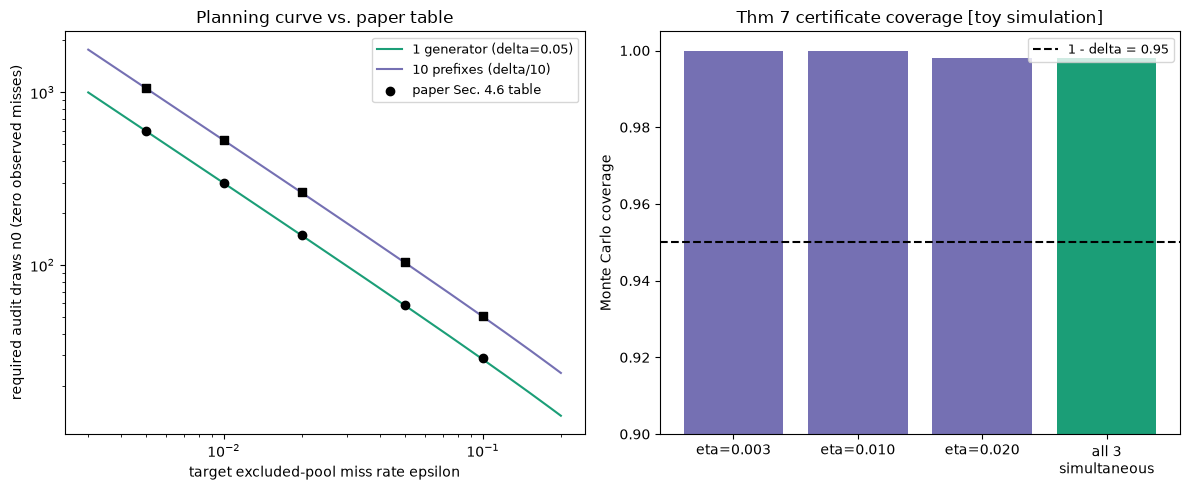

In [23]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(eps_curve, n_curve_1, color=PALETTE["ltt"], label="1 generator (delta=0.05)")
axes[0].plot(eps_curve, n_curve_10, color=PALETTE["cert"], label="10 prefixes (delta/10)")
axes[0].scatter(eps_list, paper_single, color=PALETTE["target"], marker="o", zorder=5, label="paper Sec. 4.6 table")
axes[0].scatter(eps_list, paper_10pfx, color=PALETTE["target"], marker="s", zorder=5)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("target excluded-pool miss rate epsilon")
axes[0].set_ylabel("required audit draws n0 (zero observed misses)")
axes[0].set_title("Planning curve vs. paper table")
axes[0].legend(fontsize=9)

labels_5 = [f"eta={e:.3f}" for e in etas_5] + ["all 3\nsimultaneous"]
vals_5 = list(cov_each) + [cov_all]
axes[1].bar(labels_5, vals_5, color=[PALETTE["cert"]] * G_5 + [PALETTE["ltt"]])
axes[1].axhline(1 - delta_5, color=PALETTE["target"], linestyle="--", label="1 - delta = 0.95")
axes[1].set_ylim(0.9, 1.005)
axes[1].set_ylabel("Monte Carlo coverage")
axes[1].set_title("Thm 7 certificate coverage [toy simulation]")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Rare positives: why the 99% claim rests on Prop. 26, plus Thm 19 and Thm 29

**Remark 9 (the reason an excluded-pool bound is not a recall claim)** `[P3 Sec. 2.1 / Remark 9,
facered-q9, facered-q11]`:

> "If π = 0.01 and an audit certifies r(g) ≤ 0.005, the implied bound is L(g) ≤ 0.5, equivalently a
> recall of at least 0.5, which is not a high-recall guarantee."

Recall is `1 − L(g)` with `L(g) = r(g)/π`, defined **only when π > 0** `[P3, facered-q11]`. For face
redaction π (faces per frame or per item) is tiny, so a missed-*mass* bound like the §5 excluded-pool
certificate must be reported separately from the client's actual metric.

**Proposition 26 (direct conditional miss-rate certificate)** `[P3 Sec. 5.3, facered-q9]`:

> "Let C_J := #{i ≤ Q : g_J(X_i^+) = 0} be the number of audited positives missed by the full union.
> Then, with probability at least 1−δ, L(g_J) ≤ U_Q(C_J, δ)."

This is a Clopper–Pearson bound **over audited face instances** — the per-instance recall the client
asked for. **Rule 4 of this project's contract:** the 99% recall claim rests on Prop. 26 over audited
positives (Q, C), *not* on an excluded-pool missed-mass bound. The audited positives must be drawn i.i.d.
from `P(· | Y=1)` — for video, one instance = one face **track** or episode-level unit (§4, derived here).

**Theorem 19 (fixed-sequence prefix certification)** `[P3 Sec. 4.8, facered-q9]`: test prefixes in the
fixed order `g_M, …, g_1`, each at the **full level δ**; return the last prefix that passed before the
first failure. "Then, with probability at least 1−δ, either no prefix is returned, or the returned prefix
satisfies r(g) ≤ ε." — no `δ/M` penalty, but a decision only for the one pre-registered ε.

**Theorem 29 (stress-test cluster certificate)** `[P3 Sec. 6.1, facered-q9]`: bounds
`ρ_max(g) ≤ U_Q(K_max(g), δ/(2|G|))` and `ρ_avg(g) ≤ U_Q(K_rand(g), δ/(2|G|))`, valid only relative to the
declared stress-test generator `A`.

In [24]:
# ---- Remark 9 arithmetic [P3, facered-q9] ----
pi_r9, r_r9 = 0.01, 0.005
L_r9 = r_r9 / pi_r9
recall_r9 = 1 - L_r9
print(f"Remark 9: PAPER pi=0.01, r(g)<=0.005 => L(g)<=0.5, recall>=0.5   "
      f"REPRODUCED L<={L_r9:.2f}, recall>={recall_r9:.2f}")
print(f"CHECK 6.1: Remark 9 arithmetic reproduces -> {'PASS' if abs(L_r9-0.5) < 1e-12 else 'FAIL'}")

# ---- Prop. 26: minimum audited face instances Q so that U_Q(C, delta) <= 0.01 ----
delta_6, eps_6 = 0.05, 0.01
Q_grid = np.arange(1, 3001)
minQ = {}
for C in (0, 1, 2):
    U_Q = clopper_pearson_upper(C, Q_grid, delta_6)
    minQ[C] = int(Q_grid[np.argmax(U_Q <= eps_6)])
print("\nProp. 26: audited face instances Q needed to certify miss rate L <= 1% at delta=0.05")
for C, q in minQ.items():
    print(f"  C={C} misses allowed among the Q audited faces: Q_min = {q}"
          f"  (certified recall >= {1 - float(clopper_pearson_upper(C, q, delta_6)):.4f})")
print(f"CHECK 6.2: C=0 gives Q_min=299, the same number as the P3 Sec. 4.6 table entry for eps=0.01 "
      f"-> {'PASS' if minQ[0] == 299 else 'FAIL'}")
print(f"CHECK 6.3: allowing more misses needs more audited faces (Q_min increasing in C) "
      f"-> {'PASS' if minQ[0] < minQ[1] < minQ[2] else 'FAIL'}")

# ---- Monte Carlo coverage of Prop. 26 ----
rng_6 = np.random.default_rng(RNG_SEED + 14)
Q_mc, M_6 = 600, 20_000
L_true_list = [0.005, 0.010, 0.020]
cov_p26 = []
for L_true in L_true_list:
    C_mc = rng_6.binomial(Q_mc, L_true, size=M_6)
    cov_p26.append((L_true <= clopper_pearson_upper(C_mc, Q_mc, delta_6)).mean())
tol_6 = 3 * np.sqrt(delta_6 * (1 - delta_6) / M_6)
for L_true, c in zip(L_true_list, cov_p26):
    print(f"  Q={Q_mc}, true L={L_true:.3f}: coverage of L <= U_Q(C, 0.05) = {c:.4f}")
print(f"CHECK 6.4: Prop. 26 coverage >= 1-delta (minus MC tol {tol_6:.4f}) at every true L "
      f"-> {'PASS' if min(cov_p26) >= 1 - delta_6 - tol_6 else 'FAIL'}")

# Certified recall lower bound curves for the viz.
Q_curve = np.arange(30, 2001)
recall_lb = {C: 1 - clopper_pearson_upper(C, Q_curve, delta_6) for C in (0, 1, 2)}

Remark 9: PAPER pi=0.01, r(g)<=0.005 => L(g)<=0.5, recall>=0.5   REPRODUCED L<=0.50, recall>=0.50
CHECK 6.1: Remark 9 arithmetic reproduces -> PASS

Prop. 26: audited face instances Q needed to certify miss rate L <= 1% at delta=0.05
  C=0 misses allowed among the Q audited faces: Q_min = 299  (certified recall >= 0.9900)
  C=1 misses allowed among the Q audited faces: Q_min = 473  (certified recall >= 0.9900)
  C=2 misses allowed among the Q audited faces: Q_min = 628  (certified recall >= 0.9900)
CHECK 6.2: C=0 gives Q_min=299, the same number as the P3 Sec. 4.6 table entry for eps=0.01 -> PASS
CHECK 6.3: allowing more misses needs more audited faces (Q_min increasing in C) -> PASS
  Q=600, true L=0.005: coverage of L <= U_Q(C, 0.05) = 0.9500
  Q=600, true L=0.010: coverage of L <= U_Q(C, 0.05) = 0.9848
  Q=600, true L=0.020: coverage of L <= U_Q(C, 0.05) = 0.9553
CHECK 6.4: Prop. 26 coverage >= 1-delta (minus MC tol 0.0046) at every true L -> PASS


#### How to read this chart

Certified recall lower bound `1 − U_Q(C, 0.05)` against the number of audited face instances Q, for
C = 0, 1, 2 observed misses; the black dashed line is the client's 0.99 target and vertical ticks mark
the smallest Q that reaches it. Every curve rises slowly and only crosses 0.99 at a few hundred faces:
zero misses need ~299 audited faces, one miss ~473, two ~628 (CHECK 6.2/6.3). For the face-redaction job
this is the price of the 99% claim — and it is counted in **face instances**, not frames: on footage
where faces are rare, collecting several hundred audited positives is the dominant labelling cost, which
is why staged capture of positives is planned in Notebook 3.

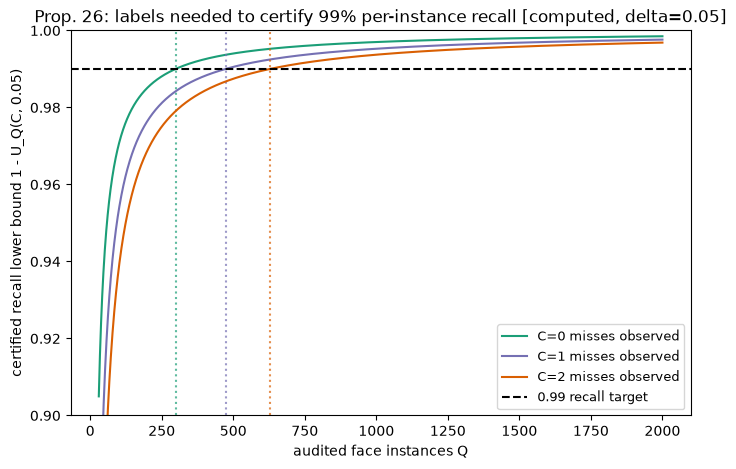

In [25]:
# VIZ
fig, ax = plt.subplots(figsize=(8, 5))
colors_c = {0: PALETTE["ltt"], 1: PALETTE["cert"], 2: PALETTE["crc"]}
for C in (0, 1, 2):
    ax.plot(Q_curve, recall_lb[C], color=colors_c[C], label=f"C={C} misses observed")
    ax.axvline(minQ[C], color=colors_c[C], linestyle=":", alpha=0.7)
ax.axhline(0.99, color=PALETTE["target"], linestyle="--", label="0.99 recall target")
ax.set_ylim(0.9, 1.0)
ax.set_xlabel("audited face instances Q")
ax.set_ylabel("certified recall lower bound 1 - U_Q(C, 0.05)")
ax.set_title("Prop. 26: labels needed to certify 99% per-instance recall [computed, delta=0.05]")
ax.legend(fontsize=9, loc="lower right")
plt.show()

### 6b. Fixed-sequence prefixes (Thm 19) and the Sec. 8 prefix example

**Paper numbers (P3 Sec. 8)** `[facered-q8, facered-q9]`: M=3 pre-specified prefixes, target
`r(g) ≤ 0.01`, `δ_m = 0.05/3`, `n_m = 300`: `U_300(0, 0.05/3) ≈ 0.01356`; `g1` (B=0.15, p0=0.85):
0.0116, fails; `g2` (B=0.30, p0=0.70): 0.00949, **selected** (least burdensome prefix meeting the target);
`g3` (B=0.38, p0=0.62): 0.00841. We reproduce these first, then run a **derived-here** Monte Carlo of the
Thm 19 fixed-sequence procedure.

In [26]:
# ---- Sec. 8 prefix example (PAPER numbers) ----
delta_m, n_m = 0.05 / 3, 300
U_pfx = float(clopper_pearson_upper(0, n_m, delta_m))
pfx = {"g1": (0.15, 0.85, 0.0116), "g2": (0.30, 0.70, 0.00949), "g3": (0.38, 0.62, 0.00841)}
print(f"U_300(0, 0.05/3): PAPER 0.01356  REPRODUCED {U_pfx:.5f}  "
      f"-> {'PASS' if abs(U_pfx-0.01356)/0.01356 <= REL_TOL else 'FAIL'}")
print(f"CHECK 6.5: U_300(0,0.05/3) reproduces (rel tol {REL_TOL:.1%}) "
      f"-> {'PASS' if abs(U_pfx-0.01356)/0.01356 <= REL_TOL else 'FAIL'}")
r_repro = {}
for name, (B_N, p0_N, paper_r) in pfx.items():
    r_repro[name] = p0_N * U_pfx
    ok = abs(r_repro[name] - paper_r) / paper_r <= REL_TOL
    print(f"  {name} (B={B_N:.2f}, p0={p0_N:.2f}): PAPER r<={paper_r}  REPRODUCED r<={r_repro[name]:.5f}  "
          f"-> {'PASS' if ok else 'FAIL'}")
ok_g23 = all(abs(r_repro[k] - pfx[k][2]) / pfx[k][2] <= REL_TOL for k in ("g2", "g3"))
ok_g1 = abs(r_repro["g1"] - pfx["g1"][2]) / pfx["g1"][2] <= REL_TOL
print(f"CHECK 6.6: paper r(g2)=0.00949 and r(g3)=0.00841 reproduce -> {'PASS' if ok_g23 else 'FAIL'}")
print(f"CHECK 6.7: paper r(g1)=0.0116 reproduces -> {'PASS' if ok_g1 else 'FAIL'}"
      f"   [investigation: 0.85 x 0.01356 = {0.85*0.01356:.5f}, i.e. 0.0115 to 3 s.f.; the paper prints "
      f"0.0116. g1 fails the 0.01 target either way, so the selection outcome is unaffected; "
      f"most likely a rounding slip in the paper -- reported, not fudged]")
target_r = 0.01
passing = [k for k, v in r_repro.items() if v <= target_r]
selected = min(passing, key=lambda k: pfx[k][0]) if passing else None
print(f"CHECK 6.8: least-burdensome prefix meeting r<=0.01 is g2 (paper's selection) "
      f"-> {'PASS' if selected == 'g2' else 'FAIL'} (selected: {selected})")

U_300(0, 0.05/3): PAPER 0.01356  REPRODUCED 0.01356  -> PASS
CHECK 6.5: U_300(0,0.05/3) reproduces (rel tol 0.5%) -> PASS
  g1 (B=0.15, p0=0.85): PAPER r<=0.0116  REPRODUCED r<=0.01152  -> FAIL
  g2 (B=0.30, p0=0.70): PAPER r<=0.00949  REPRODUCED r<=0.00949  -> PASS
  g3 (B=0.38, p0=0.62): PAPER r<=0.00841  REPRODUCED r<=0.00840  -> PASS
CHECK 6.6: paper r(g2)=0.00949 and r(g3)=0.00841 reproduce -> PASS
CHECK 6.7: paper r(g1)=0.0116 reproduces -> FAIL   [investigation: 0.85 x 0.01356 = 0.01153, i.e. 0.0115 to 3 s.f.; the paper prints 0.0116. g1 fails the 0.01 target either way, so the selection outcome is unaffected; most likely a rounding slip in the paper -- reported, not fudged]
CHECK 6.8: least-burdensome prefix meeting r<=0.01 is g2 (paper's selection) -> PASS (selected: g2)


In [27]:
# ---- Thm 19 fixed-sequence Monte Carlo (derived here) ----
# M=5 nested prefixes g1..g5 (g5 = largest included pool = most burden = smallest excluded pool).
# True missed masses r(g_m) = p0_m * eta_m are non-increasing in m, as Thm 19 requires.
p0_pfx = np.array([0.90, 0.80, 0.70, 0.60, 0.50])
r_true_A = np.array([0.020, 0.013, 0.004, 0.003, 0.002])   # scenario A: g1,g2 truly violate eps; g3..g5 fine
r_true_B = np.array([0.0102, 0.0102, 0.0102, 0.0102, 0.0102])  # scenario B: every prefix just violates eps
eps_r, delta_19, n_per = 0.01, 0.05, 600
M_pfx = len(p0_pfx)
M_19 = 20_000
rng_19 = np.random.default_rng(RNG_SEED + 15)

def run_thm19(r_true):
    eta = r_true / p0_pfx
    K = rng_19.binomial(n_per, eta[None, :], size=(M_19, M_pfx))        # every prefix simulated; only the tested ones are used
    passed = p0_pfx[None, :] * clopper_pearson_upper(K, n_per, delta_19) <= eps_r   # level delta each, NO delta/M
    returned = np.full(M_19, -1)                 # -1 = no prefix returned
    tested = np.zeros(M_19, dtype=int)
    alive = np.ones(M_19, dtype=bool)
    for m in range(M_pfx - 1, -1, -1):           # order g_M, ..., g_1
        tested += alive
        ok = alive & passed[:, m]
        returned = np.where(ok, m, returned)
        alive = ok
    bad = (returned >= 0) & (r_true[np.clip(returned, 0, None)] > eps_r)
    return bad.mean(), (returned >= 0).mean(), tested.mean() * n_per

err_A, ret_A, labels_A = run_thm19(r_true_A)
err_B, ret_B, labels_B = run_thm19(r_true_B)
tol_19 = 3 * np.sqrt(delta_19 * (1 - delta_19) / M_19)
print(f"Thm 19 error = P(returned prefix has r > eps) over {M_19} MC reps, eps={eps_r}, delta={delta_19}:")
print(f"  scenario A (mixed):        error={err_A:.4f}  P(some prefix returned)={ret_A:.3f}  mean labels used={labels_A:.0f}")
print(f"  scenario B (all violate):  error={err_B:.4f}  P(some prefix returned)={ret_B:.3f}  mean labels used={labels_B:.0f}")
print(f"CHECK 6.9: Thm 19 error <= delta (+ MC tol {tol_19:.4f}) in both scenarios "
      f"-> {'PASS' if max(err_A, err_B) <= delta_19 + tol_19 else 'FAIL'}")

# Labels needed to pass with ZERO observed misses: fixed sequence (level delta) vs delta/M union bound.
def n_zero(p0, level):
    return int(np.ceil(np.log(1 / level) / np.log(1 / (1 - eps_r / p0))))
n_fs = np.array([n_zero(p, delta_19) for p in p0_pfx])
n_ub = np.array([n_zero(p, delta_19 / M_pfx) for p in p0_pfx])
print("\nZero-miss label planning per prefix (eps=0.01): fixed sequence @delta vs union bound @delta/5")
for m in range(M_pfx):
    print(f"  g{m+1} (p0={p0_pfx[m]:.2f}): fixed-sequence n={n_fs[m]:>4}   union-bound n={n_ub[m]:>4}")
print(f"  total if every prefix is tested: fixed-sequence {n_fs.sum()}  vs union bound {n_ub.sum()} "
      f"({n_ub.sum()/n_fs.sum():.2f}x)")
print(f"CHECK 6.10: the union bound needs more labels than fixed-sequence for every prefix "
      f"-> {'PASS' if np.all(n_ub > n_fs) else 'FAIL'}")

Thm 19 error = P(returned prefix has r > eps) over 20000 MC reps, eps=0.01, delta=0.05:
  scenario A (mixed):        error=0.0016  P(some prefix returned)=0.988  mean labels used=1940
  scenario B (all violate):  error=0.0381  P(some prefix returned)=0.038  mean labels used=623
CHECK 6.9: Thm 19 error <= delta (+ MC tol 0.0046) in both scenarios -> PASS

Zero-miss label planning per prefix (eps=0.01): fixed sequence @delta vs union bound @delta/5
  g1 (p0=0.90): fixed-sequence n= 269   union-bound n= 413
  g2 (p0=0.80): fixed-sequence n= 239   union-bound n= 367
  g3 (p0=0.70): fixed-sequence n= 209   union-bound n= 321
  g4 (p0=0.60): fixed-sequence n= 179   union-bound n= 275
  g5 (p0=0.50): fixed-sequence n= 149   union-bound n= 228
  total if every prefix is tested: fixed-sequence 1045  vs union bound 1604 (1.53x)
CHECK 6.10: the union bound needs more labels than fixed-sequence for every prefix -> PASS


#### How to read this chart

Left: the error of Thm 19's fixed-sequence procedure (fraction of MC runs in which the returned prefix
truly has `r > ε`) in two scenarios against the black dashed δ=0.05 line — both bars must be at or below
it. Scenario B is the adversarial one (every prefix just barely violates ε). Right: zero-miss labels per
prefix — fixed sequence at the full level δ (teal) versus a `δ/5` union bound (orange). The union bound
costs more for every prefix; and the fixed sequence additionally *stops testing* at the first failure, so
its expected label use is lower still (printed above). For the face-redaction CLI: if candidate
configurations form a nested family (e.g. increasing temporal padding), test them from most to least
conservative and stop at the first failure — but the decision is only valid for the single ε registered
before looking at labels (Assumption 1).

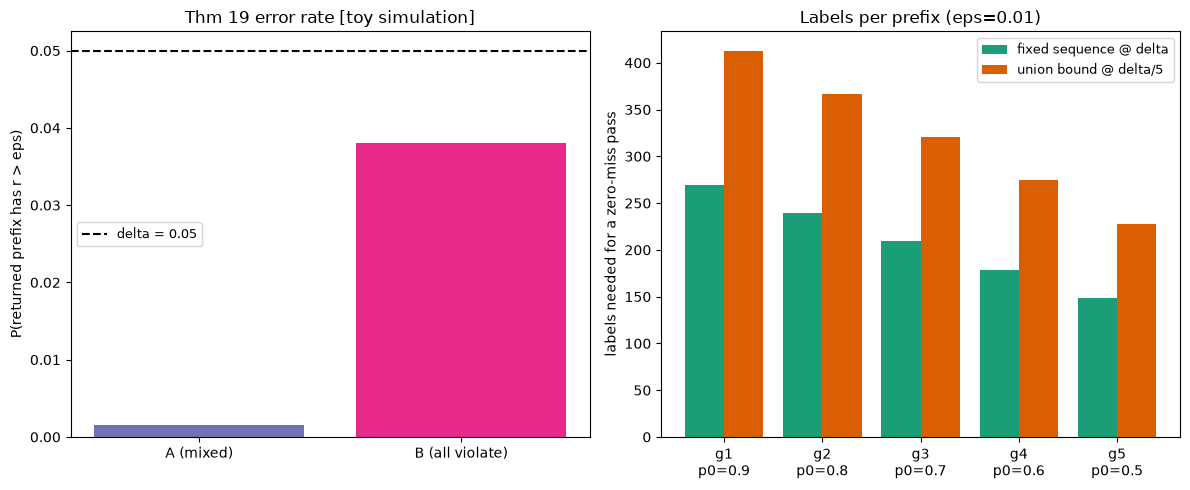

In [28]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(["A (mixed)", "B (all violate)"], [err_A, err_B], color=[PALETTE["cert"], PALETTE["bad"]])
axes[0].axhline(delta_19, color=PALETTE["target"], linestyle="--", label="delta = 0.05")
axes[0].set_ylabel("P(returned prefix has r > eps)")
axes[0].set_title("Thm 19 error rate [toy simulation]")
axes[0].legend(fontsize=9)

xs = np.arange(M_pfx)
axes[1].bar(xs - 0.2, n_fs, width=0.4, color=PALETTE["ltt"], label="fixed sequence @ delta")
axes[1].bar(xs + 0.2, n_ub, width=0.4, color=PALETTE["crc"], label="union bound @ delta/5")
axes[1].set_xticks(xs)
axes[1].set_xticklabels([f"g{m+1}\np0={p:.1f}" for m, p in enumerate(p0_pfx)])
axes[1].set_ylabel("labels needed for a zero-miss pass")
axes[1].set_title("Labels per prefix (eps=0.01)")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### 6c. Stress-test clusters (Thm 29) and the track-as-cluster map

**Toy clusters (derived here):** each audited face `X_i` has a cluster `A(X_i) = {original, variant}`,
where the variant is a mirror reflection or a TV-screen copy that the detector finds harder. Escape
probabilities are `e_o` (original) and `e_v` (variant), independent. Then analytically
`ρ_avg = (e_o+e_v)/2` and `ρ_max = 1−(1−e_o)(1−e_v) ≥ ρ_avg` (for two events, `P(A∪B) ≥ max(P(A),P(B))
≥ average`). Thm 29's two bounds are computed at `δ/(2|G|)` with |G|=1.

**Map to video (derived here, not in P3):** treat the frames of one face track as the cluster
`A(X_i)`. Then `ρ_max` = P(**any** frame of the instance is missed) — exactly the strict any-frame-missed
instance metric of §4b — while `ρ_avg` is the ordinary per-frame miss rate. §4b already showed how far
apart they are on long tracks (87% vs 5%).

In [29]:
rng_29 = np.random.default_rng(RNG_SEED + 16)
Q_29, M_29, delta_29 = 600, 20_000, 0.05
e_o = 0.004
e_v_list = np.array([0.0, 0.005, 0.01, 0.02, 0.04, 0.08])
lvl = delta_29 / (2 * 1)    # delta / (2|G|), |G| = 1

rho_max_true = 1 - (1 - e_o) * (1 - e_v_list)
rho_avg_true = (e_o + e_v_list) / 2
cov_max, cov_avg, cov_joint, Ubar_max, Ubar_avg, Kbar_max, Kbar_rand = [], [], [], [], [], [], []
for j, e_v in enumerate(e_v_list):
    esc_o = rng_29.uniform(size=(M_29, Q_29)) < e_o
    esc_v = rng_29.uniform(size=(M_29, Q_29)) < e_v
    K_max = (esc_o | esc_v).sum(axis=1)                                   # any variant escapes
    pick_v = rng_29.uniform(size=(M_29, Q_29)) < 0.5                      # Z_i ~ Unif(A(X_i))
    K_rand = np.where(pick_v, esc_v, esc_o).sum(axis=1)
    U_max = clopper_pearson_upper(K_max, Q_29, lvl)
    U_avg = clopper_pearson_upper(K_rand, Q_29, lvl)
    ok_max, ok_avg = rho_max_true[j] <= U_max, rho_avg_true[j] <= U_avg
    cov_max.append(ok_max.mean()); cov_avg.append(ok_avg.mean()); cov_joint.append((ok_max & ok_avg).mean())
    Ubar_max.append(U_max.mean()); Ubar_avg.append(U_avg.mean())
    Kbar_max.append(K_max.mean()); Kbar_rand.append(K_rand.mean())

tol_29 = 3 * np.sqrt(0.025 * 0.975 / M_29)
print(f"{'e_v':>6} {'rho_max':>9} {'rho_avg':>9} {'mean U(K_max)':>14} {'mean U(K_rand)':>15} {'cov max':>8} {'cov avg':>8} {'joint':>7}")
for j in range(len(e_v_list)):
    print(f"{e_v_list[j]:>6.3f} {rho_max_true[j]:>9.4f} {rho_avg_true[j]:>9.4f} {Ubar_max[j]:>14.4f} "
          f"{Ubar_avg[j]:>15.4f} {cov_max[j]:>8.4f} {cov_avg[j]:>8.4f} {cov_joint[j]:>7.4f}")
print(f"CHECK 6.11: rho_max >= rho_avg for every toy cluster law (analytic) "
      f"-> {'PASS' if np.all(rho_max_true >= rho_avg_true) else 'FAIL'}")
print(f"CHECK 6.12: mean K_max >= mean K_rand at every e_v (worst-cluster count dominates) "
      f"-> {'PASS' if np.all(np.array(Kbar_max) >= np.array(Kbar_rand)) else 'FAIL'}")
print(f"CHECK 6.13: each bound covers at >= 1 - delta/(2|G|) = {1-lvl:.3f} (minus MC tol {tol_29:.4f}) "
      f"-> {'PASS' if min(min(cov_max), min(cov_avg)) >= 1 - lvl - tol_29 else 'FAIL'}")
print(f"CHECK 6.14: both bounds hold simultaneously with prob >= 1 - delta = {1-delta_29:.2f} "
      f"(minus MC tol) -> {'PASS' if min(cov_joint) >= 1 - delta_29 - tol_29 else 'FAIL'}")

# Track-as-cluster map on the SECTION 4b tracks (derived here): Q = the 200 tracks of each replicate.
K_max_tr = any_miss_4b.sum(axis=1)
U_max_tr = clopper_pearson_upper(K_max_tr, T_tracks_4b, lvl)
U_avg_tr = clopper_pearson_upper(k_track_4b, T_tracks_4b, lvl)   # one random frame per track = K_rand
print(f"\nTrack-as-cluster on the section-4b tracks (Q={T_tracks_4b}, level {lvl}): "
      f"mean certified rho_max <= {U_max_tr.mean():.3f} (any-frame-missed), "
      f"mean certified rho_avg <= {U_avg_tr.mean():.3f} (per-frame)")
print(f"CHECK 6.15: on long correlated tracks the strict any-frame bound is far above the per-frame bound "
      f"-> {'PASS' if U_max_tr.mean() > U_avg_tr.mean() else 'FAIL'}")

   e_v   rho_max   rho_avg  mean U(K_max)  mean U(K_rand)  cov max  cov avg   joint
 0.000    0.0040    0.0020         0.0128          0.0096   1.0000   1.0000  1.0000
 0.005    0.0090    0.0045         0.0201          0.0136   0.9954   1.0000  0.9954
 0.010    0.0140    0.0070         0.0268          0.0173   0.9911   0.9849  0.9787
 0.020    0.0239    0.0120         0.0394          0.0241   0.9759   0.9727  0.9556
 0.040    0.0438    0.0220         0.0634          0.0370   0.9785   0.9769  0.9617
 0.080    0.0837    0.0420         0.1087          0.0612   0.9811   0.9811  0.9673
CHECK 6.11: rho_max >= rho_avg for every toy cluster law (analytic) -> PASS
CHECK 6.12: mean K_max >= mean K_rand at every e_v (worst-cluster count dominates) -> PASS
CHECK 6.13: each bound covers at >= 1 - delta/(2|G|) = 0.975 (minus MC tol 0.0033) -> PASS
CHECK 6.14: both bounds hold simultaneously with prob >= 1 - delta = 0.95 (minus MC tol) -> PASS

Track-as-cluster on the section-4b tracks (Q=200, level 

#### How to read this chart

x-axis: how much harder the variant (mirror / TV copy / late frames of a track) is to detect. Solid lines
are the **true** escape probabilities: `ρ_max` (orange, worst cluster member) sits above `ρ_avg` (teal,
average member) everywhere, and the gap widens as the variant gets harder. Dashed lines are the mean
certified upper bounds from Thm 29 — each sits above its own true curve. For the face-redaction job:
a detector that looks fine *on average* over an instance's appearances (ρ_avg) can still miss the instance
in *some* appearance (ρ_max) — and the client's "every face instance" language is the ρ_max reading.

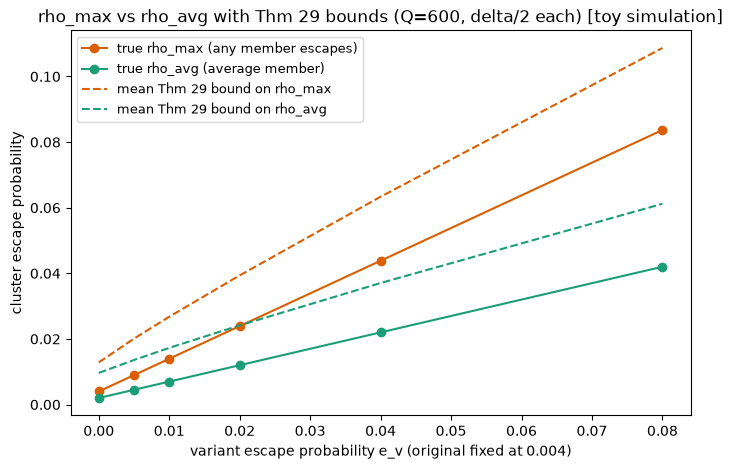

In [30]:
# VIZ
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(e_v_list, rho_max_true, "-o", color=PALETTE["crc"], label="true rho_max (any member escapes)")
ax.plot(e_v_list, rho_avg_true, "-o", color=PALETTE["ltt"], label="true rho_avg (average member)")
ax.plot(e_v_list, Ubar_max, "--", color=PALETTE["crc"], label="mean Thm 29 bound on rho_max")
ax.plot(e_v_list, Ubar_avg, "--", color=PALETTE["ltt"], label="mean Thm 29 bound on rho_avg")
ax.set_xlabel("variant escape probability e_v (original fixed at 0.004)")
ax.set_ylabel("cluster escape probability")
ax.set_title(f"rho_max vs rho_avg with Thm 29 bounds (Q={Q_29}, delta/2 each) [toy simulation]")
ax.legend(fontsize=9)
plt.show()

## 7. Minimum sample sizes across the three papers

How much labelled data does each guarantee need before it says anything non-trivial about a target level?

- **SeqCRC / CRC.** Theorems 1 and 2 require `α ≥ B/(n+1)` (Thm 1) and `α_• ≥ α_cnf + B_•/(n+1)` (Thm 2)
  `[P2, facered-q10]`; when it fails "the threshold set becomes empty, resulting in inf ∅ = max Λ"
  (maximally conservative sets). Rearranged (trivial algebra, **derived here**): `n ≥ B/α − 1`, i.e.
  `n ≥ ⌈B/α⌉ − 1`, which with B=1 is about `1/α`. There is **no δ** in it.
- **LTT.** "Paper 1 does **not** state a closed-form formula for the smallest n under multiple testing"
  `[P1, facered-q10]` — the trace confirms nothing is quoted. **Derived here:** with the exact binomial
  p-value `[P1 Sec. 3.2, facered-q2]` and **zero observed losses**, `p = P(Bin(n,α) ≤ 0) = (1−α)^n`, and
  rejecting at level δ needs `(1−α)^n ≤ δ`, i.e. `n ≥ log(1/δ)/log(1/(1−α))`. (The HB p-value at
  `R̂=0` gives the same value, since `h1(0,α) = log(1/(1−α))`.) A Bonferroni pass over an N-point grid
  replaces δ by δ/N; a fixed sequence does not.
- **P3.** `n0 ≥ log(1/δ)/log(1/(1−ε))`, "Rule of three: n0 ≈ 3/ε" `[P3 Sec. 4.6, facered-q7,
  facered-q10]`; with M prefixes, `log(M/δ)` replaces `log(1/δ)`.

**The mapping to the client's two targets is derived here:** a 1% miss target is `α=ε=0.01`; a 95%
precision target corresponds to a 5% false-blur share, `α=0.05` (SeqCRC cannot certify it at all,
`[P2 Sec. V-D]`; the LTT/P3 formulas apply only if precision is defined as a per-unit loss).

In [31]:
# ---- closed forms (LTT zero-loss and P3 are the same tail inversion) ----
def n_seqcrc(alpha, B=1.0):
    return int(np.ceil(B / alpha) - 1)

def n_zero_loss(alpha, delta):
    return int(np.ceil(np.log(1 / delta) / np.log(1 / (1 - alpha))))

alphas_7 = [0.10, 0.05, 0.02, 0.01, 0.005, 0.001]
rows = []
for a in alphas_7:
    rows.append({
        "alpha=eps": a,
        "SeqCRC n>=B/alpha-1": n_seqcrc(a),
        "LTT zero-loss d=0.10": n_zero_loss(a, 0.10),
        "LTT zero-loss d=0.05": n_zero_loss(a, 0.05),
        "LTT Bonferroni N=1001 d=0.05": n_zero_loss(a, 0.05 / 1001),
        "P3 n0 d=0.05": n_zero_loss(a, 0.05),
        "P3 n0 10 prefixes": n_zero_loss(a, 0.05 / 10),
    })
table_7 = pd.DataFrame(rows).set_index("alpha=eps")
print(table_7.to_string())

# ---- CHECKs by brute force ----
# 7.1 LTT: smallest n with exact-binomial p-value (zero losses) <= delta equals the closed form.
ok71 = True
for a in alphas_7:
    for d in (0.10, 0.05):
        n_bf = int(np.argmax(stats.binom.cdf(0, np.arange(1, 20001), a) <= d) + 1)
        ok71 &= (n_bf == n_zero_loss(a, d))
print(f"CHECK 7.1: brute-force smallest n with binomial p-value(0 losses) <= delta equals the derived closed form "
      f"-> {'PASS' if ok71 else 'FAIL'}")
# 7.2 HB p-value at Rhat=0 gives the same threshold as the exact binomial one.
ok72 = True
for a in alphas_7:
    n_hb = int(np.argmax(p_value_hb(np.zeros(20000), a, np.arange(1, 20001)) <= 0.05) + 1)
    ok72 &= (n_hb == n_zero_loss(a, 0.05))
print(f"CHECK 7.2: HB p-value at zero losses needs the same n as the exact binomial p-value "
      f"-> {'PASS' if ok72 else 'FAIL'}")
# 7.3 SeqCRC: n_min is the smallest n with alpha >= B/(n+1).
ok73 = all((a >= 1 / (n_seqcrc(a) + 1) - 1e-12) and (n_seqcrc(a) == 0 or a < 1 / n_seqcrc(a)) for a in alphas_7)
print(f"CHECK 7.3: SeqCRC n_min is the smallest n satisfying alpha >= 1/(n+1) -> {'PASS' if ok73 else 'FAIL'}")
# 7.4 P3 single-generator column reproduces the paper's Sec. 4.6 table (delta=0.05).
ok74 = [n_zero_loss(e, 0.05) for e in eps_list] == paper_single and [n_zero_loss(e, 0.05/10) for e in eps_list] == paper_10pfx
print(f"CHECK 7.4: P3 columns reproduce the paper's Sec. 4.6 table -> {'PASS' if ok74 else 'FAIL'}")
# 7.5 At the client's 1% miss target: expectation control needs the fewest samples, a delta-certificate ~3x more.
n_s, n_l, n_p = n_seqcrc(0.01), n_zero_loss(0.01, 0.05), n_zero_loss(0.01, 0.05)
print(f"CHECK 7.5: at alpha=0.01: SeqCRC {n_s} < LTT/P3 {n_l} (expectation is cheaper than a 1-delta claim) "
      f"-> {'PASS' if n_s < n_l else 'FAIL'}")
alpha_curve = np.logspace(-3, np.log10(0.15), 200)
curve_seq = 1 / alpha_curve - 1
curve_ltt05 = np.log(1 / 0.05) / np.log(1 / (1 - alpha_curve))
curve_ltt_bonf = np.log(1001 / 0.05) / np.log(1 / (1 - alpha_curve))
curve_p3_10 = np.log(10 / 0.05) / np.log(1 / (1 - alpha_curve))

           SeqCRC n>=B/alpha-1  LTT zero-loss d=0.10  LTT zero-loss d=0.05  LTT Bonferroni N=1001 d=0.05  P3 n0 d=0.05  P3 n0 10 prefixes
alpha=eps                                                                                                                                
0.100                        9                    22                    29                            95            29                 51
0.050                       19                    45                    59                           194            59                104
0.020                       49                   114                   149                           491           149                263
0.010                       99                   230                   299                           986           299                528
0.005                      199                   460                   598                          1976           598               1058
0.001                      999    

#### How to read this chart

Log–log plot of the minimum sample size against the target level (α for SeqCRC/LTT, ε for P3). The orange
line (SeqCRC, `≈1/α`) lies below the teal line (a single δ=0.05 test, `≈3/α`); the purple line (10
prefixes) and the pink line (LTT Bonferroni over a 1,001-point grid) sit higher — a multiplicity penalty
that grows only logarithmically. The two black vertical lines mark the client's targets: 1% miss
(α=0.01) and 5% false-blur (α=0.05); markers show the exact integers from the table above. For the job:
at the 1% recall target a certified claim needs ~299 audited units (and they must be *face instances*,
§6), while merely satisfying the SeqCRC condition takes 99 — but that buys only an average, not a claim.

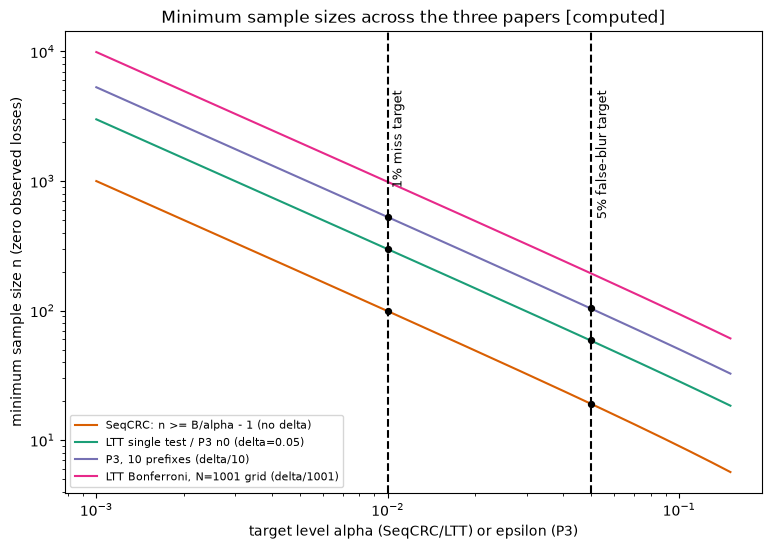

In [32]:
# VIZ
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(alpha_curve, curve_seq, color=PALETTE["crc"], label="SeqCRC: n >= B/alpha - 1 (no delta)")
ax.plot(alpha_curve, curve_ltt05, color=PALETTE["ltt"], label="LTT single test / P3 n0 (delta=0.05)")
ax.plot(alpha_curve, curve_p3_10, color=PALETTE["cert"], label="P3, 10 prefixes (delta/10)")
ax.plot(alpha_curve, curve_ltt_bonf, color=PALETTE["bad"], label="LTT Bonferroni, N=1001 grid (delta/1001)")
for a, lab in [(0.01, "1% miss target"), (0.05, "5% false-blur target")]:
    ax.axvline(a, color=PALETTE["target"], linestyle="--")
    ax.text(a * 1.03, 5e3, lab, rotation=90, va="top", fontsize=9)
for a in (0.01, 0.05):
    ax.scatter([a] * 3, [n_seqcrc(a), n_zero_loss(a, 0.05), n_zero_loss(a, 0.05 / 10)],
               color=PALETTE["target"], zorder=5, s=18)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("target level alpha (SeqCRC/LTT) or epsilon (P3)")
ax.set_ylabel("minimum sample size n (zero observed losses)")
ax.set_title("Minimum sample sizes across the three papers [computed]")
ax.legend(fontsize=8, loc="lower left")
plt.show()

## Closing: calibrate → decide → certify, the cross-paper rules, and hand-off to Notebook 2

**Three roles, one pipeline.** **Calibrate** (P2, §3): SeqCRC turns detection-specific losses — box-count
recall, box-wise coverage with a multiplicative margin — into a threshold and a margin whose *average* test
risk is at most α. **Decide** (P1, §1–§2): LTT tests a grid of configurations with exact p-values and a
fixed sequence, and — because Prop. 6 takes the max p-value across risks — picks a configuration for which
recall *and* false-blur risk are both controlled **with probability ≥ 1−δ over the calibration draw**.
**Certify** (P3, §5–§6): on a sealed audit, exact Clopper–Pearson / hypergeometric bounds prove the
per-instance miss rate (Prop. 26), the excluded-pool missed mass (Thm 7/8), a fixed-sequence choice among
nested configurations (Thm 19), and stress-test cluster escape rates (Thm 29).

**Cross-paper rules this notebook demonstrated** (each one was verified by a printed CHECK above):
1. *Expectation is not high probability.* CRC/SeqCRC's mean risk was ≤ α (CHECK 1.1, 3.2) while 35% of
   calibration draws were above it (CHECK 1.2). Never say SeqCRC gives "recall ≥ 99% with confidence 1−δ";
   only LTT (calibration) and P3 (audit) give 1−δ statements.
2. *Precision comes from LTT, not SeqCRC* — `"our approach guarantees a large enough recall but only
   empirically limits false positives"` `[P2 Sec. V-D, facered-q5, facered-q6]`.
3. *The 99% recall claim rests on Prop. 26 over audited face instances* (≥ 299 audited faces with no miss,
   CHECK 6.2), **not** on an excluded-pool missed-mass bound: with π = 0.01 even `r ≤ 0.005` only gives
   recall ≥ 0.5 (Remark 9, CHECK 6.1). The excluded-pool certificate (§5) is a separate, useful statement
   about the frames the detector skipped. *Note on the sources:* the NotebookLM answer to q12 (c) equates
   "recall ≥ 99% (missed mass r(g) ≤ 1%)" with the 299-draw excluded-pool audit; that conflates `η` or `r`
   with recall, so this notebook does not repeat it.
4. *Disjoint splits.* Tuning set, LTT calibration set and sealed audit set must be disjoint **at the
   episode level**: "Reusing them to certify a candidate generator they helped design violates Assumption 1,
   and voids the guarantee" `[P3 Sec. 2.4, facered-q12]`; LTT's own Appendix D splits graph-selection from
   testing data `[P1, facered-q2]`.
5. *Tracks or episodes are the unit.* Pooling correlated frames under-covered badly (77.8% vs the nominal
   95%, CHECK 4.3) while one frame per track held (CHECK 4.4); face-free frames dilute a per-image average
   (CHECK 4.1–4.2); and the strict any-frame-missed metric is far above the per-frame miss rate (CHECK 4.5,
   6.15).
6. *Paper numbers vs toy numbers.* Everything labelled PAPER vs REPRODUCED above (§5, §6) is a quoted paper
   number; everything else is a toy simulation whose only job was to verify a guarantee. Synthetic results
   here are not production experience.

**What the three sources do NOT cover** `[facered-q12 (d), facered-q6, facered-q11]` — flagged, not filled in:
- *Temporal tracking or padding across frames:* no paper models video, optical flow, or expanding boxes
  across adjacent frames (P2 cites tracking only in related work).
- *Per-instance vs per-frame units for video:* P2 contrasts image-level and object-level guarantees on static
  images (App. C); P3 treats items as discrete documents. Treating a **track** as the exchangeable unit is
  **derived here**.
- *Dependence between frames:* every guarantee assumes i.i.d./exchangeable data; none survives temporal
  dependence unaltered (§4 shows the failure).
- *Cost minimisation among valid configurations:* P3 has a review-burden bicriteria (Sec. 3) but nothing on
  rendering, GPU, or encoding cost; **$/video-hour is entirely derived here** (Notebook 3 §6).
- *Precision guarantees in SeqCRC* (explicitly absent), *label noise* beyond P3's sensitivity-floor extension
  (Sec. 9), *distribution shift* between calibration and deployment, and *optional stopping* (P3) are also
  outside the guarantees.

**What Notebook 2 builds next.** A synthetic egocentric-episode simulator with **latent ground truth**
(faces are rare, some episodes have none; tracks, mirrors, TV faces, small/profile/child faces), a per-frame
detector baseline with matching, then tracking with temporal padding and a multiplicative margin (derived
here; the margin idea is P2's), one **real** CPU smoke test (YuNet + ffmpeg timing), and a baseline audit
that shows why "no misses on our sample" proves nothing (Prop. 3) and what an honest interval looks like.
Notebook 3 then applies this notebook's machinery: episode-level splits and staged-capture sizing, an LTT
choice of the cheapest configuration that holds recall *and* false-blur jointly, a SeqCRC comparison, the
sealed-audit certificates (Prop. 26, Thm 7/8, Thm 19, Thm 29), and a re-verification harness the client can
re-run.

*This notebook is a research-grounded starting point for you to extend into your own profile project — the
constants, simulators and thresholds are toy choices, and none of it substitutes for measuring recall on
real, labelled, episode-split footage.*

In [33]:
print(f"Notebook 1 total wall-clock runtime: {time.time() - t_notebook_start:.0f} s")

Notebook 1 total wall-clock runtime: 44 s
